In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import ks_2samp
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier

from eda.scoring_function import score_model_optimal_k

In [2]:
x_train=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_train.txt",sep=" ")
x_test=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_test.txt",sep=" ")
y_train=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\y_train.txt")

# Correlation and distribution differences

In [3]:
train=pd.concat([x_train,y_train],axis=1)

In [4]:
train_true=train[train.iloc[:,500]==1]
train_false=train[train.iloc[:,500]==0]


In [5]:
x_train_true=train_true.iloc[:,:-1]
x_train_false=train_false.iloc[:,:-1]

In [6]:
corr_matrix = train.corr()


In [20]:
np.sum(y_train)

np.int64(2488)

In [7]:
target_col_name = train.columns[-1]

target_corr = corr_matrix[target_col_name]

target_corr = target_corr.drop(labels=[target_col_name])

threshold = 0.1
relevant_features = target_corr[target_corr.abs() > threshold].sort_values(ascending=False)
print(len(relevant_features))
print(relevant_features)

6
V390    0.113968
V224    0.109128
V161    0.105698
V32     0.103328
V175    0.103328
V11     0.101000
Name: y, dtype: float64


In [6]:
target_corr_sorted=target_corr.sort_values(ascending=False)

In [4]:
x_train_best_corr=x_train[["V11","V32","V161","V175","V224","V390"]]

In [10]:
sorted_col_names=target_corr_sorted.index.to_list()

In [9]:
def check_distribution_drift(df_train, df_test, threshold=0.05):
    drift_results = []

    for column in df_train.columns:
        stat, p_value = ks_2samp(df_train[column], df_test[column])
        if p_value < threshold:
            drift_results.append({
                'column': column,
                'p_value': p_value,
                'status': 'Different'
            })

    return pd.DataFrame(drift_results)

drifted_features = check_distribution_drift(x_train, x_test)
print(f"Number of drifted features: {len(drifted_features)}")

Number of drifted features: 26


In [10]:
features_with_different_distributions=check_distribution_drift(x_train_true,x_train_false)
print(f"Number of features with different distributions: {len(features_with_different_distributions)}")


Number of features with different distributions: 53


In [11]:
print(features_with_different_distributions)

   column       p_value     status
0      V3  1.846829e-02  Different
1      V5  1.274071e-04  Different
2      V6  1.423363e-02  Different
3     V11  3.353528e-13  Different
4     V32  7.772217e-09  Different
5     V46  1.850615e-08  Different
6     V55  3.808463e-02  Different
7     V60  5.257798e-08  Different
8     V72  4.401267e-02  Different
9     V78  6.492445e-03  Different
10   V117  1.399290e-04  Different
11   V120  8.748540e-05  Different
12   V127  2.755529e-02  Different
13   V146  2.175956e-02  Different
14   V160  1.477014e-06  Different
15   V161  1.867617e-11  Different
16   V175  7.772217e-09  Different
17   V176  3.002991e-12  Different
18   V179  1.920802e-02  Different
19   V185  2.269521e-02  Different
20   V191  5.128255e-11  Different
21   V198  4.622830e-02  Different
22   V199  4.634870e-08  Different
23   V215  2.973166e-04  Different
24   V221  3.637237e-02  Different
25   V224  3.263676e-13  Different
26   V227  1.348586e-02  Different
27   V255  3.286481e

In [17]:
features_with_different_distributions_names=features_with_different_distributions['column'].values

In [18]:
print(features_with_different_distributions_names)

<StringArray>
[  'V3',   'V5',   'V6',  'V11',  'V32',  'V46',  'V55',  'V60',  'V72',
  'V78', 'V117', 'V120', 'V127', 'V146', 'V160', 'V161', 'V175', 'V176',
 'V179', 'V185', 'V191', 'V198', 'V199', 'V215', 'V221', 'V224', 'V227',
 'V255', 'V256', 'V262', 'V265', 'V283', 'V291', 'V293', 'V309', 'V313',
 'V326', 'V329', 'V342', 'V345', 'V358', 'V377', 'V380', 'V390', 'V393',
 'V416', 'V427', 'V435', 'V443', 'V454', 'V464', 'V469', 'V483']
Length: 53, dtype: str


In [13]:
print(drifted_features)

   column   p_value     status
0      V9  0.013569  Different
1     V24  0.008079  Different
2     V29  0.026547  Different
3     V54  0.039677  Different
4     V55  0.017417  Different
5     V96  0.010504  Different
6    V107  0.011948  Different
7    V119  0.020915  Different
8    V141  0.003537  Different
9    V143  0.049482  Different
10   V148  0.035444  Different
11   V163  0.035444  Different
12   V190  0.035444  Different
13   V242  0.019685  Different
14   V249  0.049482  Different
15   V254  0.006174  Different
16   V276  0.015385  Different
17   V303  0.004688  Different
18   V307  0.029836  Different
19   V325  0.011205  Different
20   V326  0.022213  Different
21   V346  0.006607  Different
22   V453  0.035444  Different
23   V455  0.026547  Different
24   V477  0.014451  Different
25   V498  0.014451  Different


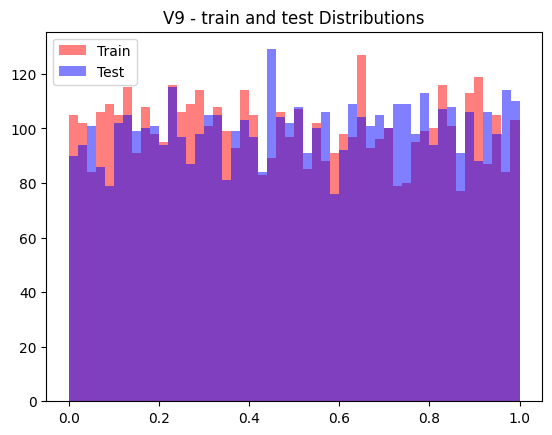

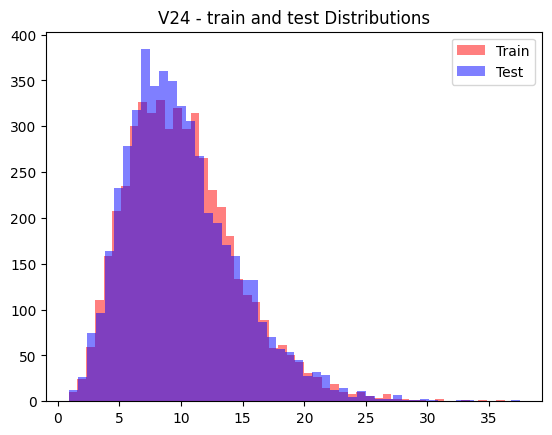

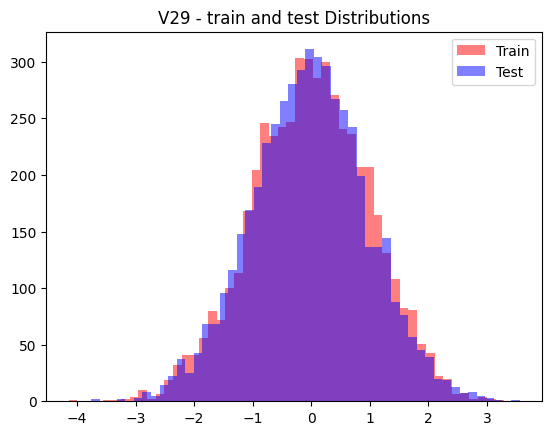

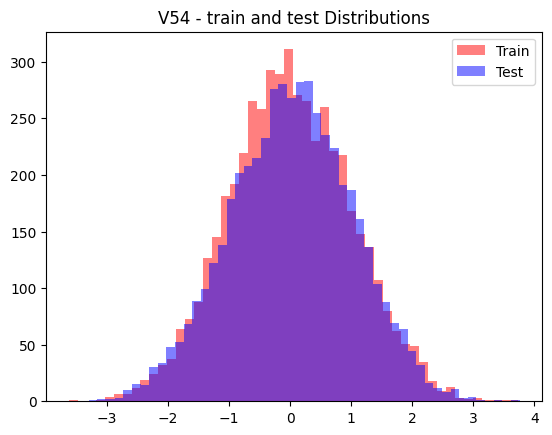

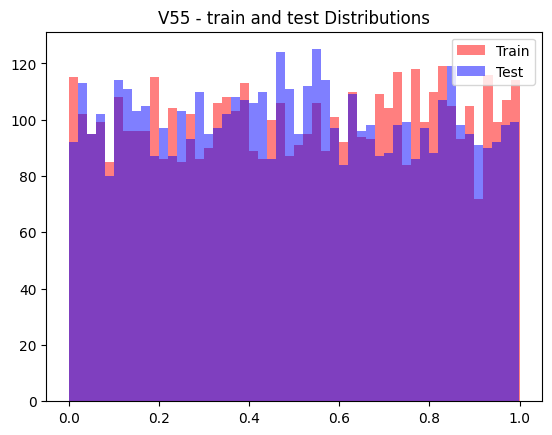

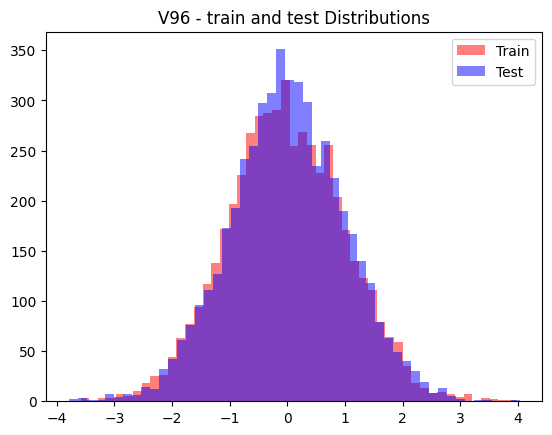

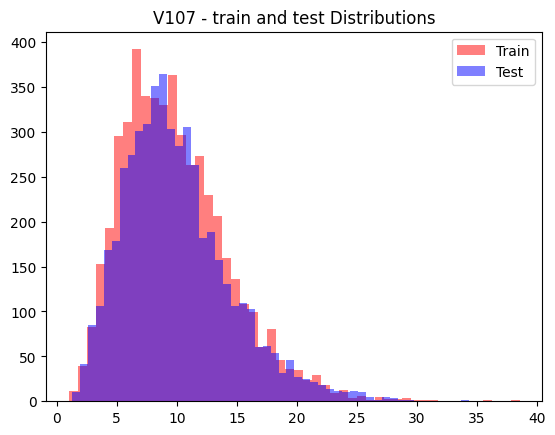

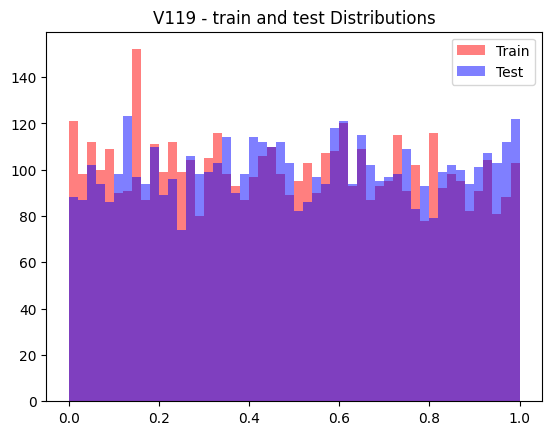

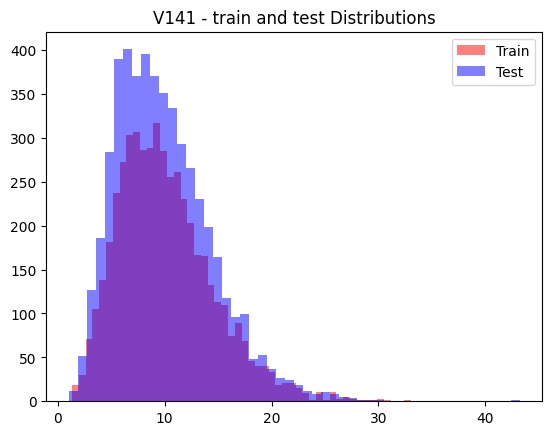

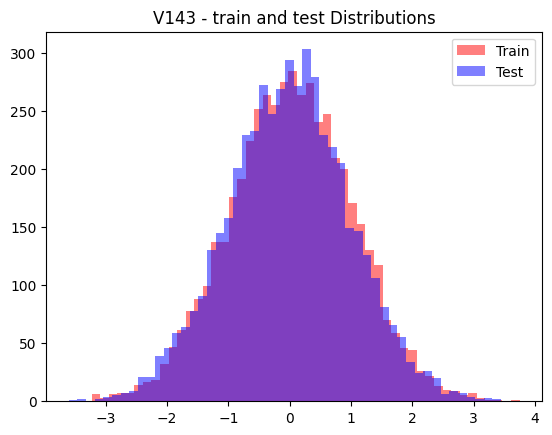

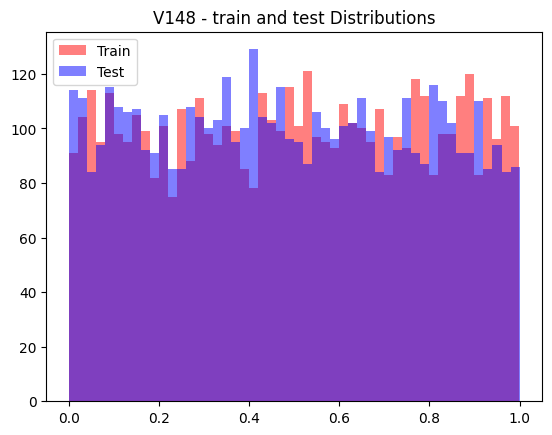

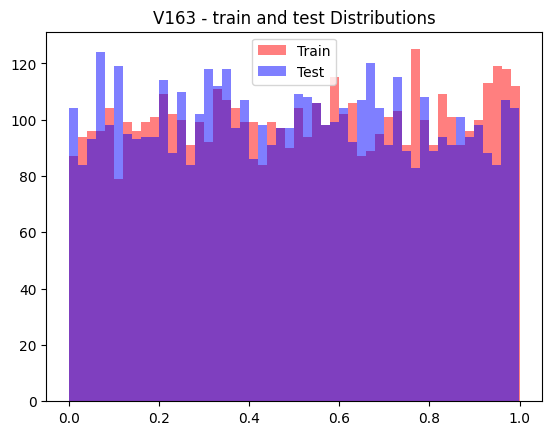

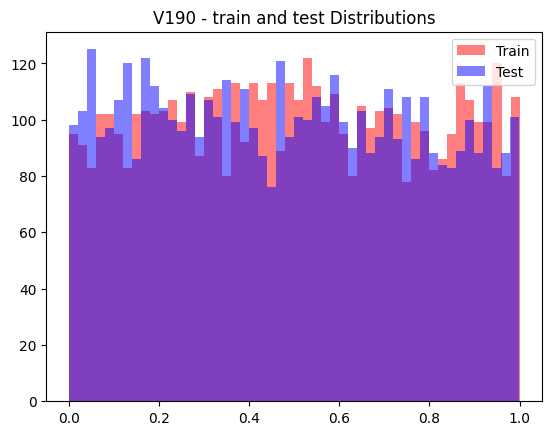

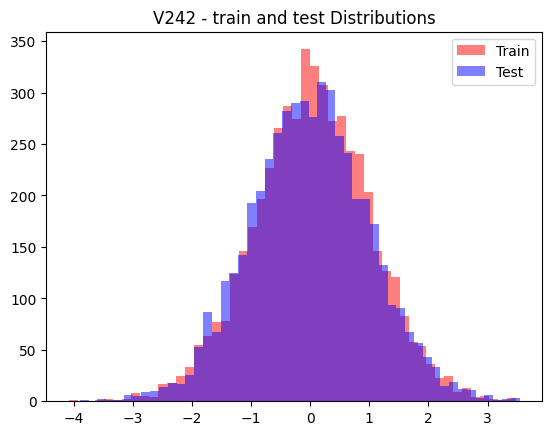

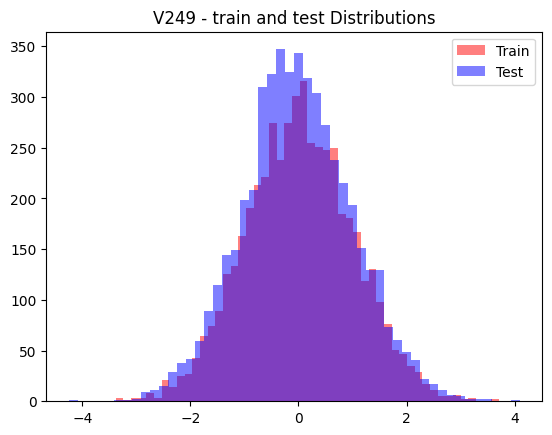

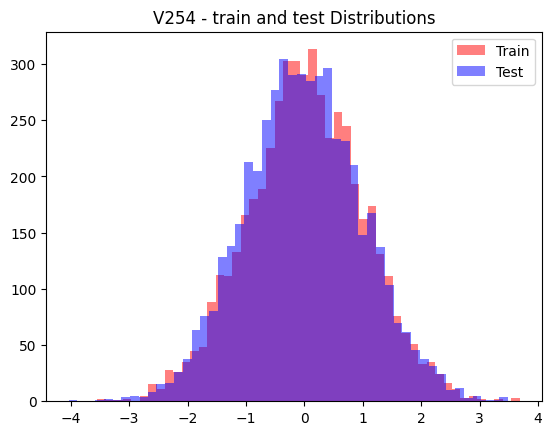

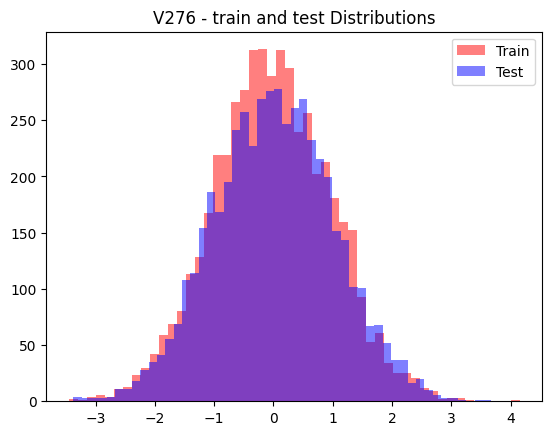

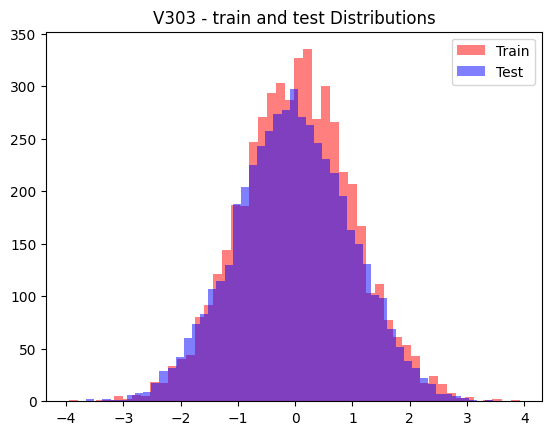

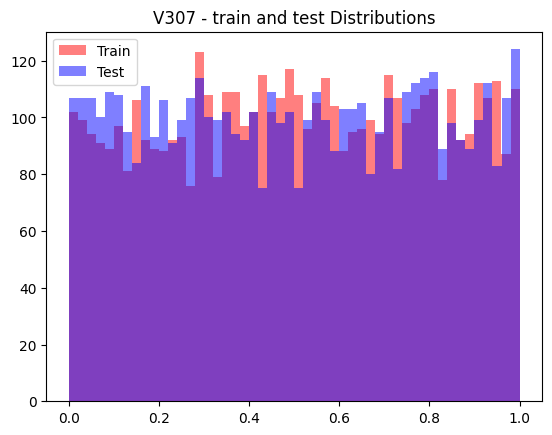

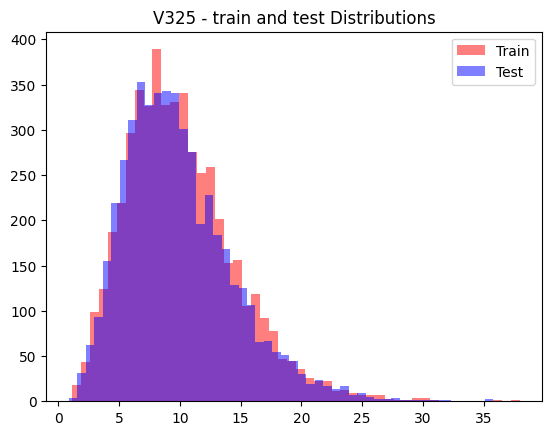

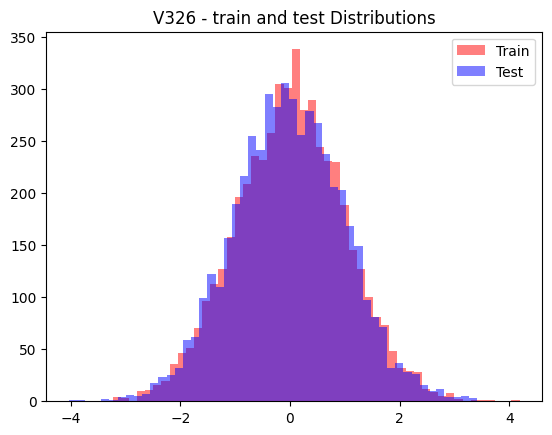

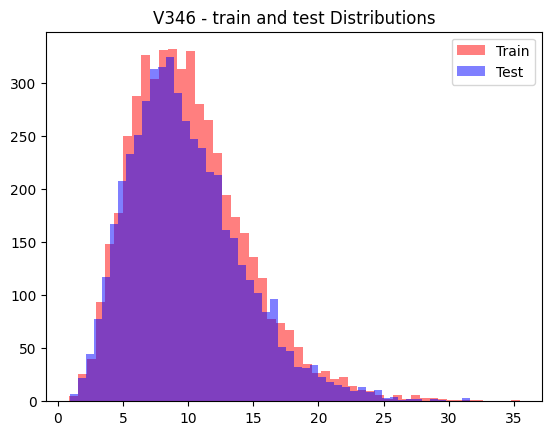

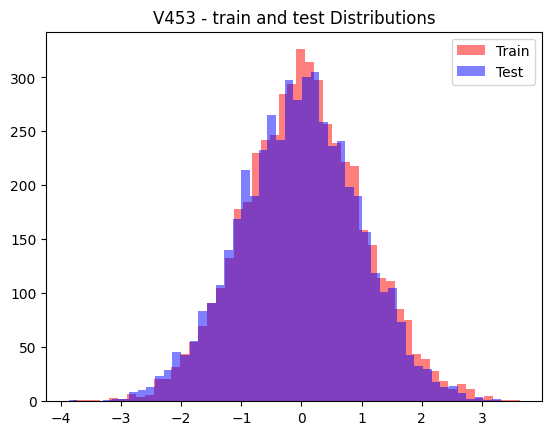

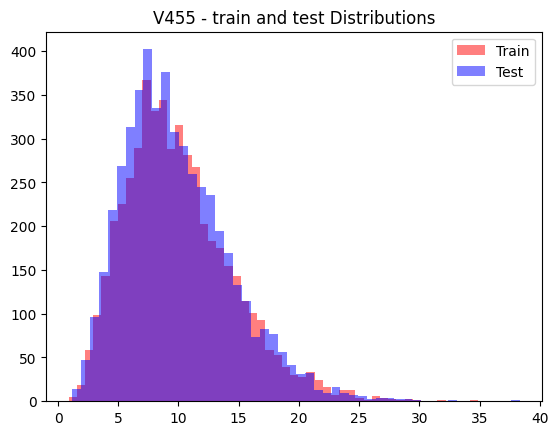

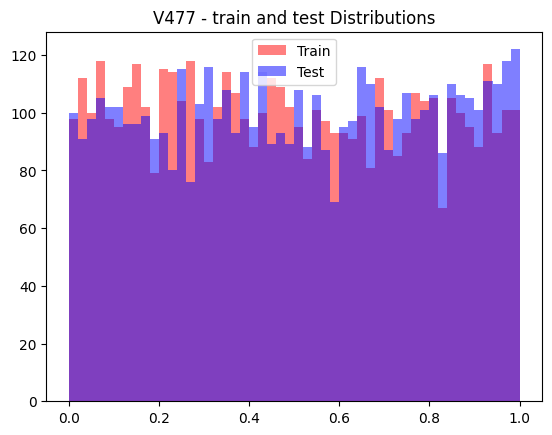

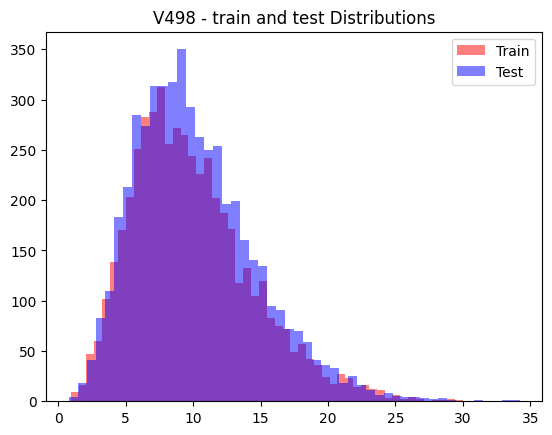

In [17]:
for i in range(len(drifted_features)):
    col_name = drifted_features.iloc[i]['column']
    plt.hist(x_train[col_name], bins=50, color='red', alpha=0.5, label='Train')
    plt.hist(x_test[col_name], bins=50, color='blue', alpha=0.5, label='Test')
    plt.legend()
    plt.title(f"{col_name} - train and test Distributions")
    plt.show()

# Simple models trial

In [15]:
lr=LogisticRegression(penalty=None)

In [13]:
def customresultscore(y_pred,y_true):
    y_pred = np.asarray(y_pred).flatten()
    y_true = np.asarray(y_true).flatten()
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    print(f"tp count={tp}, fp count={fp}")
    return tp * 10 - fp * 5

In [14]:
x_train_tr1,x_train_val,y_train_tr1,y_train_val=train_test_split(x_train,y_train,test_size=0.2,random_state=0)

In [40]:
x_train_sq=x_train**2

In [23]:
x_train_tr2,x_train_val2,y_train_tr2,y_train_val2=train_test_split(x_train,y_train,test_size=0.5,random_state=0)

In [41]:
x_train_trsq,x_train_valsq,y_train_trsq,y_train_valsq=train_test_split(x_train_sq,y_train,test_size=0.5,random_state=0)

In [52]:
custom_scores={
    0.5:np.zeros(50),
    0.6:np.zeros(50),
    0.7:np.zeros(50),
    0.8:np.zeros(50),
    0.9:np.zeros(50)
}

accuracy_scores={
    0.5:np.zeros(50),
    0.6:np.zeros(50),
    0.7:np.zeros(50),
    0.8:np.zeros(50),
    0.9:np.zeros(50)
}
precision_scores={
    0.5:np.zeros(50),
    0.6:np.zeros(50),
    0.7:np.zeros(50),
    0.8:np.zeros(50),
    0.9:np.zeros(50)
}

In [27]:
from sklearn.metrics import precision_score

In [64]:
import scoring_function
import importlib
importlib.reload(scoring_function)


<module 'scoring_function' from 'C:\\Users\\andrz\\-Cost-Sensitive-Predictive-Modeling\\eda\\scoring_function.py'>

In [69]:
top10_cols=selected_cols[:10]
submat=corr_matrix.loc[top10_cols,top10_cols]

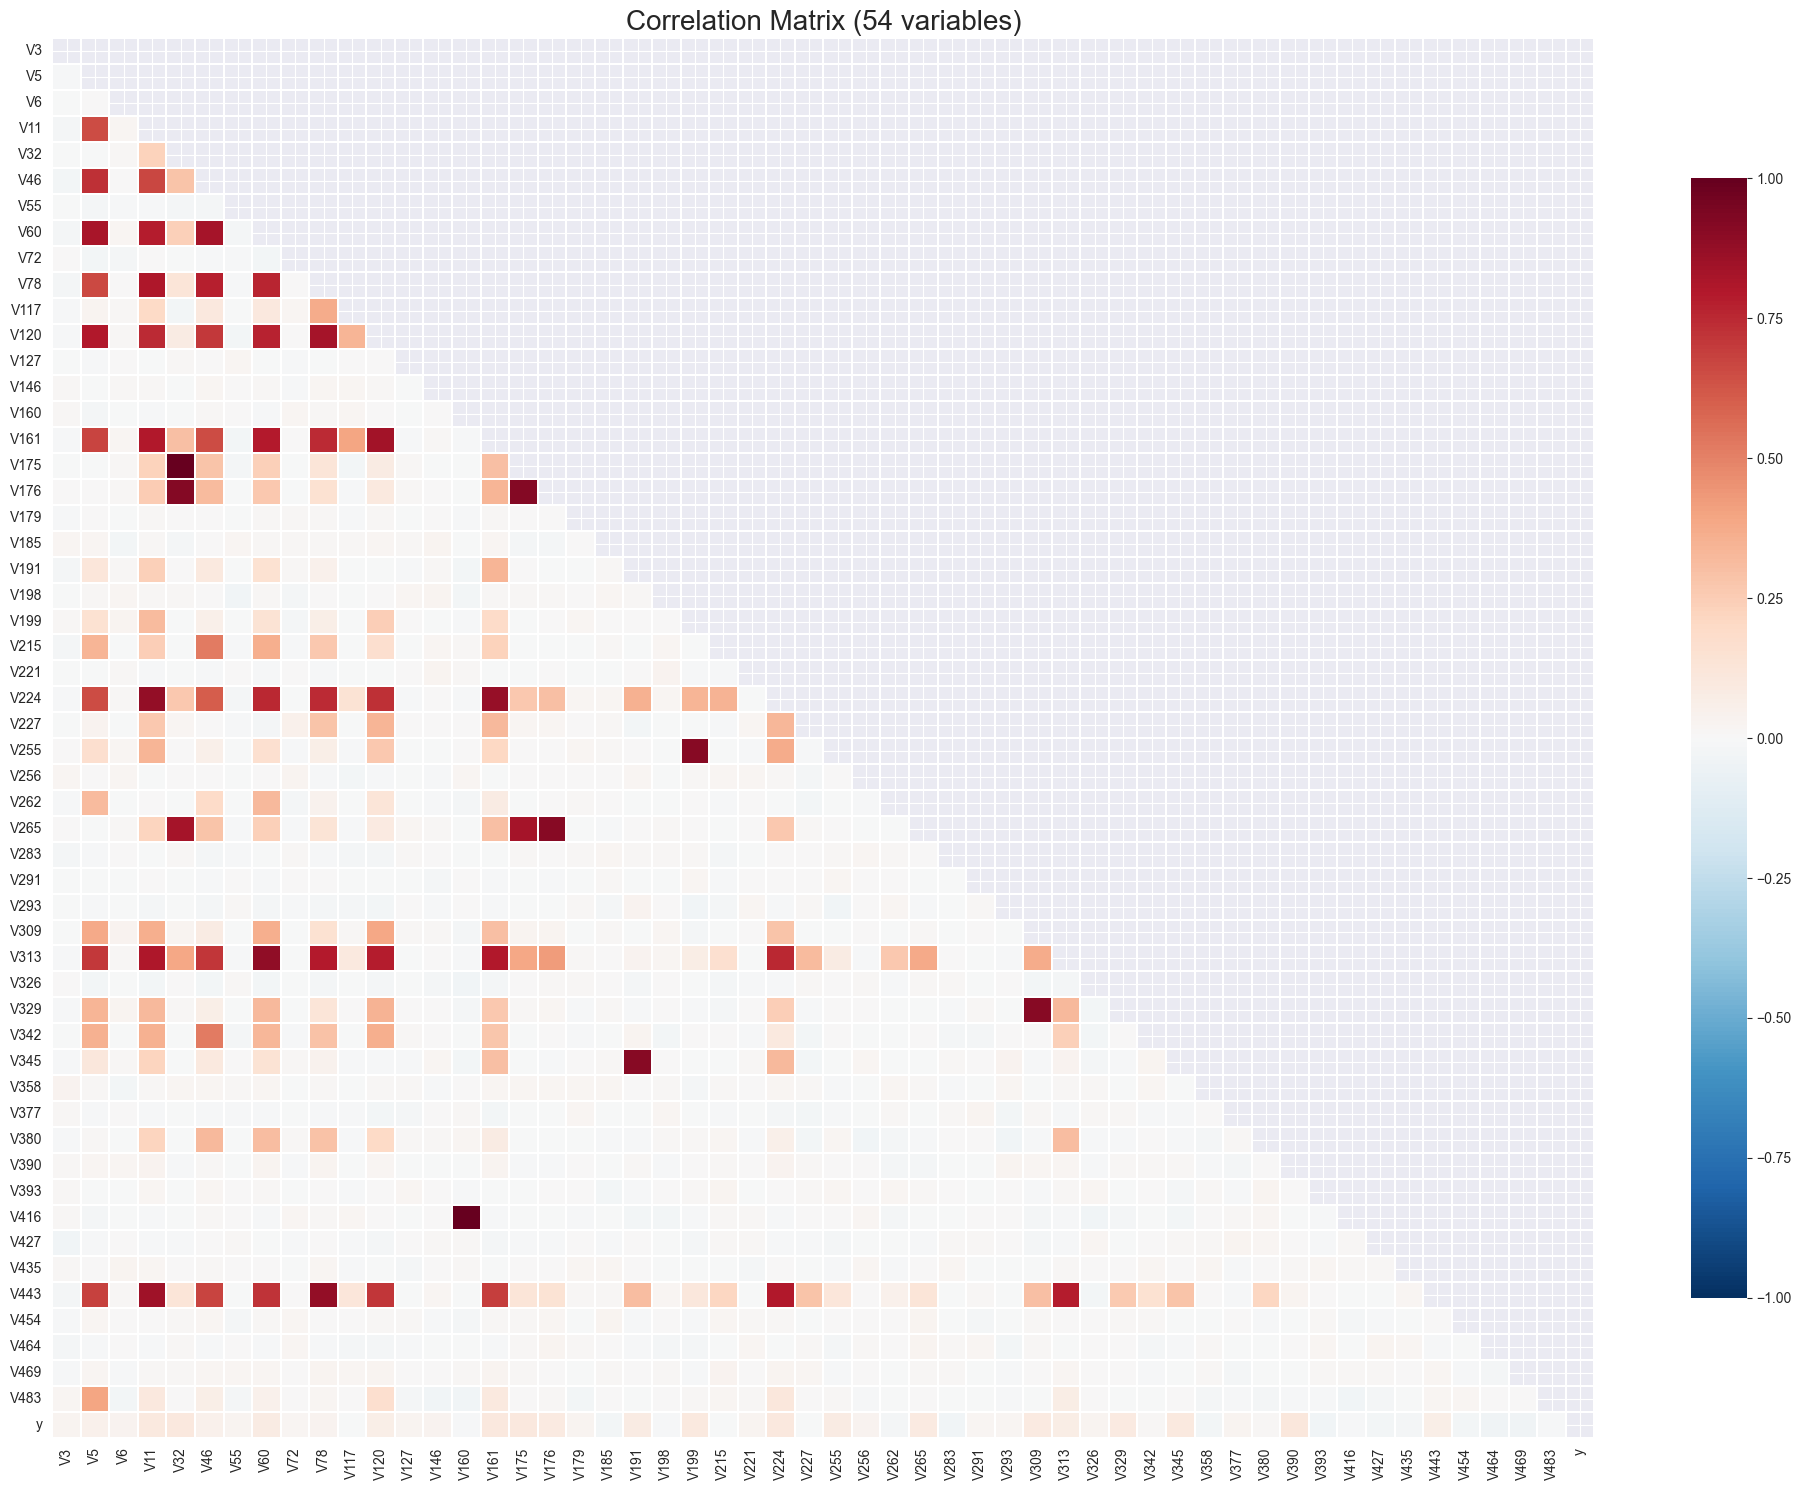

In [57]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert to list (fixing the previous error)
plot_cols = list(features_with_different_distributions_names) + [target_col_name]
submat2 = corr_matrix.loc[plot_cols, plot_cols]

# 2. Create a mask for the upper triangle
mask = np.triu(np.ones_like(submat2, dtype=bool))

# 3. Dynamic sizing
# Since you have ~50 variables, 12x12 is too small for annotations.
# We'll increase size and decrease font.
plt.figure(figsize=(20, 15))

sns.heatmap(submat2,
            mask=mask,           # Only show the bottom triangle
            annot=False,         # Turned off because 54 variables are too many for text
            cmap='RdBu_r',       # Red-Blue is often more intuitive for +/- correlations
            center=0,            # Ensure 0 is the neutral color
            linewidths=.1,
            cbar_kws={"shrink": .8},
            vmin=-1, vmax=1)

plt.title(f'Correlation Matrix ({len(plot_cols)} variables)', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [61]:
import pandas as pd
import numpy as np
from scipy import stats

def calculate_f_test(df):
    target_col = df.columns[-1]
    features = df.columns[:-1]

    # Separate the data based on the binary target (0 and 1)
    class_0 = df[df[target_col] == 0]
    class_1 = df[df[target_col] == 1]

    f_results = {}

    for col in features:
        # Perform One-way ANOVA
        f_stat, p_val = stats.f_oneway(class_0[col], class_1[col])
        f_results[col] = {'F-Score': f_stat, 'p-value': p_val}

    # Convert to DataFrame for easy viewing
    result_df = pd.DataFrame(f_results).T
    return result_df.sort_values(by='F-Score', ascending=False)

# Usage:
# f_test_results = calculate_f_test(training_df)
# print(f_test_results.head(10))

In [62]:
# Usage:
result = calculate_f_test(train)
print(result)

        F-Score       p-value
V390  65.771559  6.315617e-16
V224  60.237727  1.012505e-14
V161  56.468392  6.727861e-14
V175  53.937593  2.404064e-13
V32   53.937593  2.404064e-13
...         ...           ...
V404   0.000225  9.880209e-01
V481   0.000176  9.894041e-01
V379   0.000145  9.904031e-01
V219   0.000061  9.937759e-01
V459   0.000022  9.962883e-01

[500 rows x 2 columns]


In [16]:
from sklearn.feature_selection import mutual_info_classif
X_test_top_ten=x_test.loc[:,best_xgb_recursive_cols_on_tr2]
mi_scores = mutual_info_classif(X_test_top_ten, y_train.values.ravel())

In [6]:
full_mi_scores=mutual_info_classif(x_test,y_train.values.ravel())

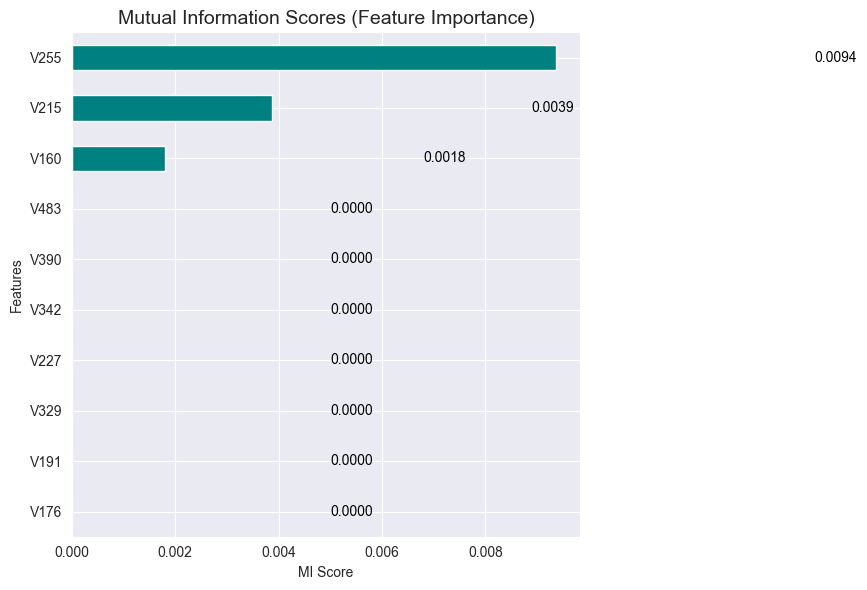

In [18]:
mi_series = pd.Series(mi_scores, name="MI Scores", index=best_xgb_recursive_cols_on_tr2)
mi_series = mi_series.sort_values(ascending=True)  # Sort for a nice 'ladder' effect

# 2. Plotting
plt.figure(figsize=(10, 6))
ax = mi_series.plot(kind='barh', color='teal')

# Add labels and title
plt.title('Mutual Information Scores (Feature Importance)', fontsize=14)
plt.xlabel('MI Score')
plt.ylabel('Features')

# Optional: Add the actual values on the bars for precision
for i, v in enumerate(mi_series):
    ax.text(v + 0.005, i, f'{v:.4f}', color='black', va='center')

plt.tight_layout()
plt.show()

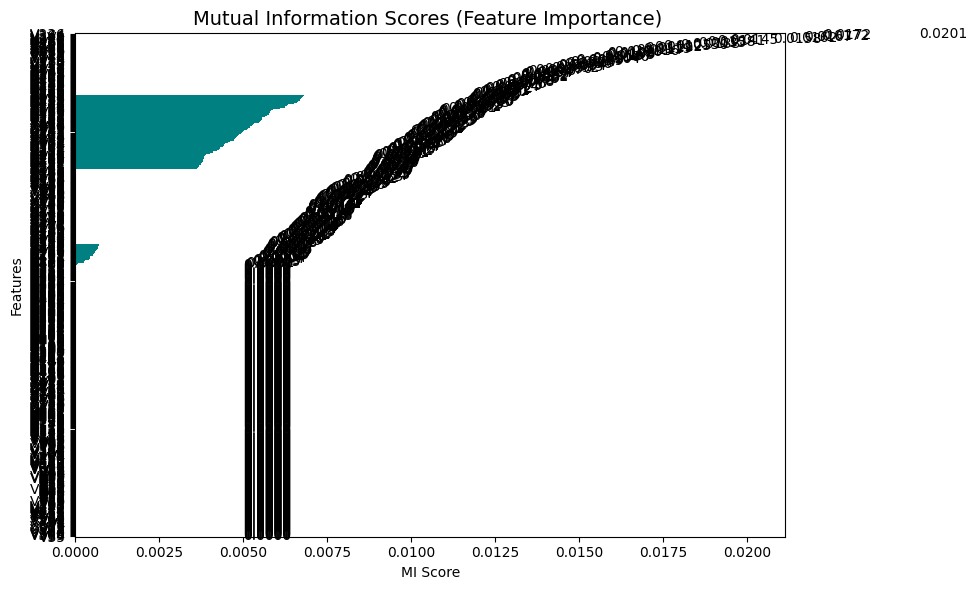

In [91]:
full_mi_series = pd.Series(full_mi_scores, name="MI Scores", index=x_train.columns)
full_mi_series = full_mi_series.sort_values(ascending=True)  # Sort for a nice 'ladder' effect

# 2. Plotting
plt.figure(figsize=(10, 6))
ax = full_mi_series.plot(kind='barh', color='teal')

# Add labels and title
plt.title('Mutual Information Scores (Feature Importance) ', fontsize=14)
plt.xlabel('MI Score')
plt.ylabel('Features')

# Optional: Add the actual values on the bars for precision
for i, v in enumerate(full_mi_series):
    ax.text(v + 0.005, i, f'{v:.4f}', color='black', va='center')

plt.tight_layout()
plt.show()

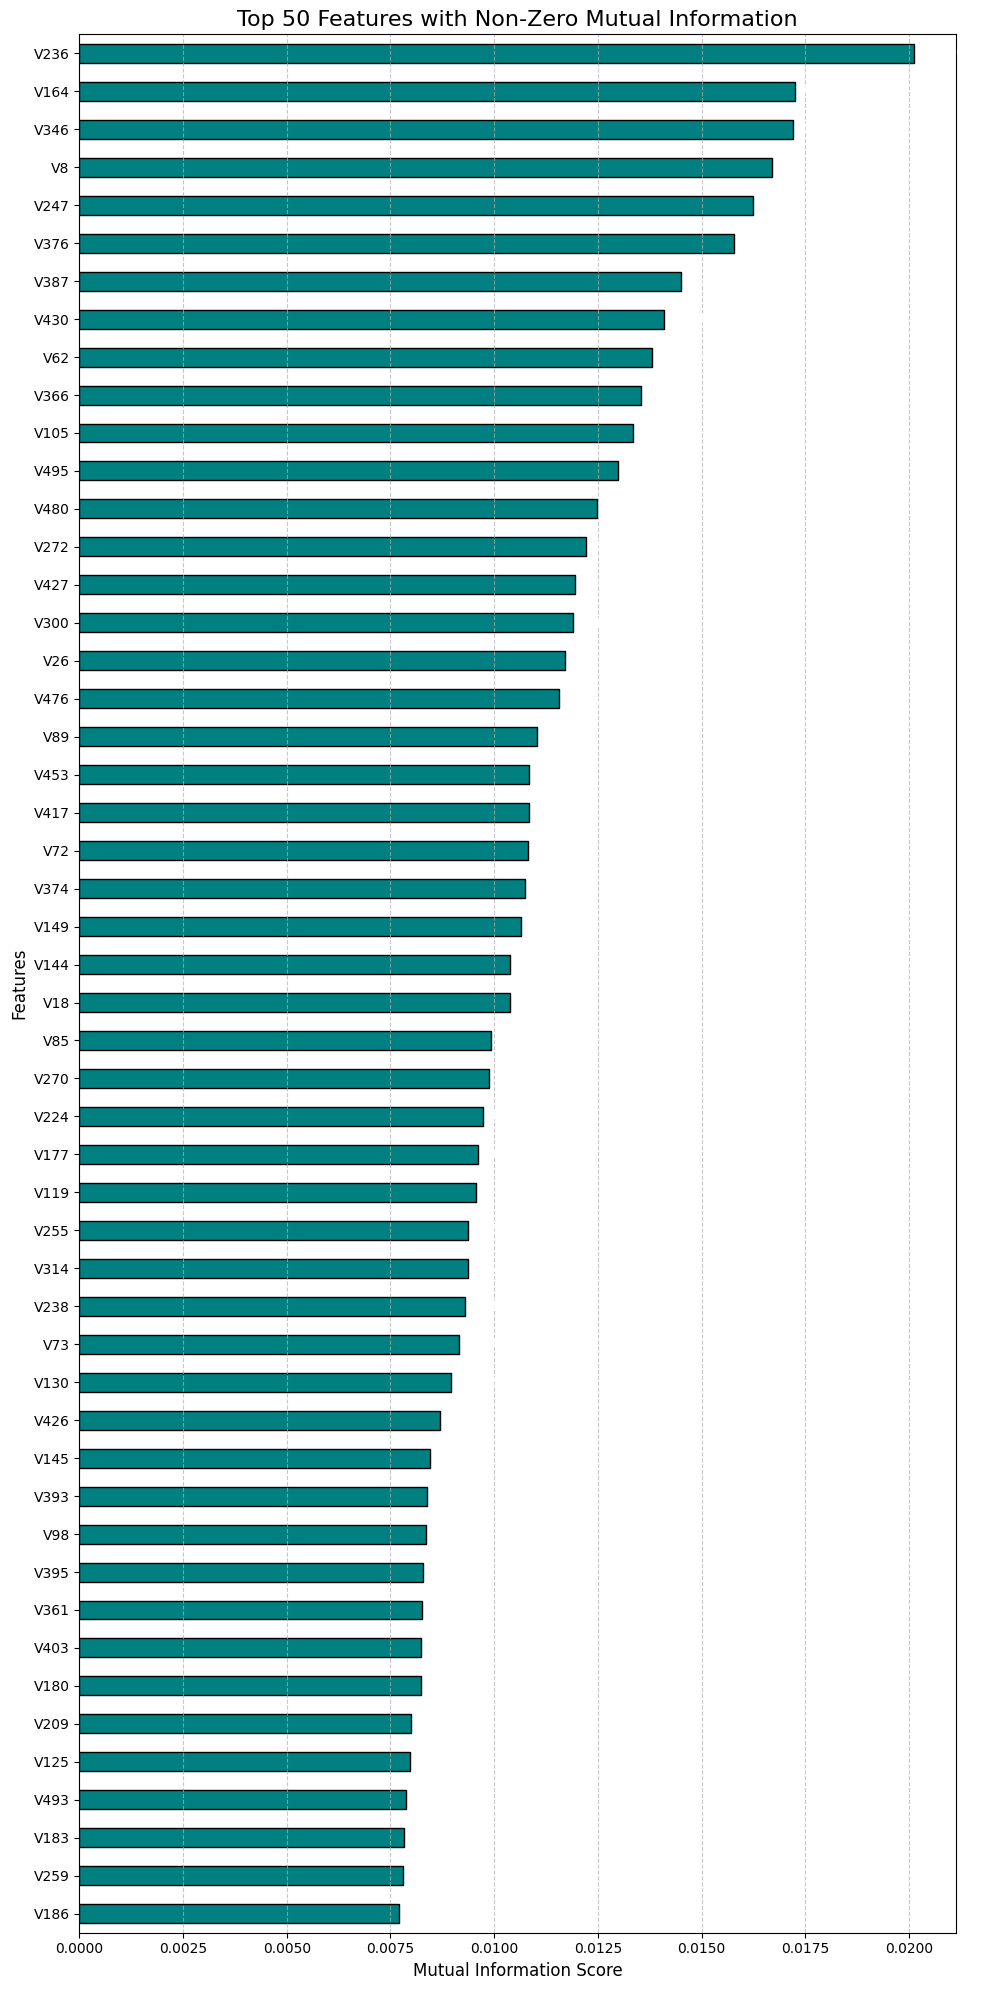

In [96]:
# 1. Filter for non-zero scores
non_zero_mi = full_mi_series[full_mi_series > 0]

# 2. Select only the Top 30 (adjust this number as needed)
# Sorting Descending to get the best, then Ascending for a pretty horizontal bar chart
top_non_zero = non_zero_mi.sort_values(ascending=False).head(50).sort_values(ascending=True)

# 3. Plot with a dynamic height based on the number of features
plt.figure(figsize=(10, len(top_non_zero) * 0.4))

ax = top_non_zero.plot(kind='barh', color='teal', edgecolor='black')

# 4. Cleanup text and labels
plt.title(f'Top {len(top_non_zero)} Features with Non-Zero Mutual Information', fontsize=16)
plt.xlabel('Mutual Information Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Adding the labels at the end of bars
for i, v in enumerate(top_non_zero):
    ax.text(v + 0.0002, i, f'{v:.4f}', color='white', va='center', fontsize=10, weight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [98]:
print(top_non_zero[40:].index)

Index(['V366', 'V62', 'V430', 'V387', 'V376', 'V247', 'V8', 'V346', 'V164',
       'V236'],
      dtype='str')


In [93]:
non_zero_features = full_mi_series[full_mi_series > 0].index.tolist()

In [95]:
print(len(non_zero_features))

230


In [19]:
best_mi_cols=['V236', 'V164', 'V346', 'V8', 'V247', 'V376', 'V387', 'V430', 'V62', 'V366']

In [20]:
best_xgb_cols=['V11', 'V265', 'V176', 'V174', 'V160', 'V191', 'V46', 'V255', 'V136', 'V425']

In [21]:
best_xgb_recursive_cols=['V117', 'V160', 'V176', 'V191', 'V215', 'V227', 'V255', 'V342', 'V380', 'V390']

In [22]:
best_xgb_recursive_cols_on_tr2=['V160', 'V176', 'V191', 'V215', 'V227', 'V255', 'V329', 'V342', 'V390', 'V483']

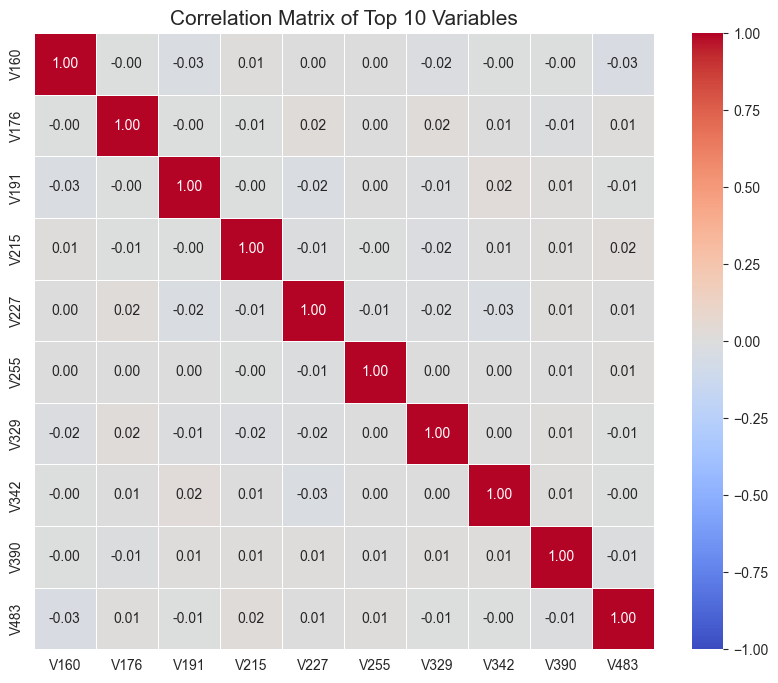

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
plot_cols = best_xgb_recursive_cols_on_tr2
# Define the sub-matrix
submat2 = corr_matrix.loc[plot_cols, plot_cols]

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(submat2,
            annot=True,          # Show the correlation values
            cmap='coolwarm',     # Color scheme
            fmt=".2f",           # Round to 2 decimal places
            linewidths=0.5,      # Add small lines between cells
            vmin=-1, vmax=1)     # Ensure the scale is anchored at -1 and 1

plt.title('Correlation Matrix of Top 10 Variables', fontsize=15)
plt.show()

In [109]:
top_20_xgb_names = xgb_top_features.head(20).index.tolist()

print("The Top 10 Features chosen by XGBoost:")
print(top_20_xgb_names)

The Top 10 Features chosen by XGBoost:
['V11', 'V265', 'V176', 'V174', 'V160', 'V191', 'V46', 'V255', 'V136', 'V425', 'V215', 'V156', 'V380', 'V342', 'V117', 'V109', 'V329', 'V227', 'V308', 'V262']


In [101]:
best_mi_cols[:1]

['V236']

In [19]:
best_xgb_recursive_cols_on_tr2_nonzero_mi=['V160', 'V215', 'V255']

In [20]:
from itertools import combinations

cols = ['V160', 'V215', 'V255']

subsets = []

for r in range(1, len(cols) + 1):
    subsets.extend(combinations(cols, r))

for i, s in enumerate(subsets, 1):
    print(i, list(s))

1 ['V160']
2 ['V215']
3 ['V255']
4 ['V160', 'V215']
5 ['V160', 'V255']
6 ['V215', 'V255']
7 ['V160', 'V215', 'V255']


In [47]:
from scoring_function import score_model_optimal_k
true_custom_scores=np.zeros(10)
true_custom_scores_best_k=np.zeros(10)
best_fp=np.zeros(10)
best_tp=np.zeros(10)
for i in range(10):
    selected_cols=best_xgb_recursive_cols[:i+1]
    train_data=x_train_trsq.loc[:,selected_cols]
    test_data=x_train_valsq.loc[:,selected_cols]
    xgb=XGBClassifier()
    xgb.fit(train_data,y_train_trsq)
    positive_probas=xgb.predict_proba(test_data)[:,1]
    true_custom_scores[i],true_custom_scores_best_k[i],best_fp[i],best_tp[i]=score_model_optimal_k(y_train_valsq,positive_probas,i+1,keep_fp_tp=True)
    if i%5==0:
        print(f"{i} iters done")

0 iters done
5 iters done


In [52]:
from scoring_function import score_model_optimal_k
true_custom_scores=np.zeros(10)
true_custom_scores_best_k=np.zeros(10)
best_fp=np.zeros(10)
best_tp=np.zeros(10)
for i in range(10):
    selected_cols=best_xgb_recursive_cols[:i+1]
    train_data=x_train_tr2.loc[:,selected_cols]
    test_data=x_train_val2.loc[:,selected_cols]
    xgb=XGBClassifier()
    xgb.fit(train_data,y_train_tr2)
    positive_probas=xgb.predict_proba(test_data)[:,1]
    true_custom_scores[i],true_custom_scores_best_k[i],best_fp[i],best_tp[i]=score_model_optimal_k(y_train_val2,positive_probas,i+1,keep_fp_tp=True)
    if i%5==0:
        print(f"{i} iters done")

0 iters done
5 iters done


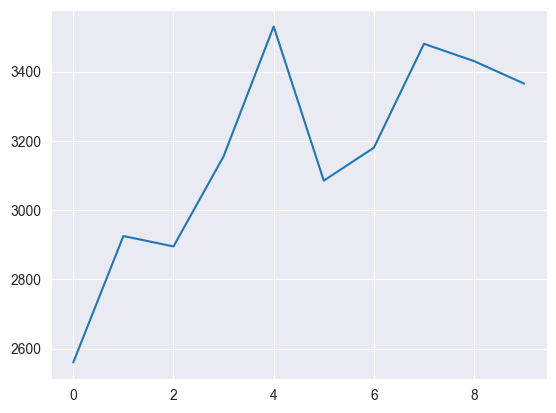

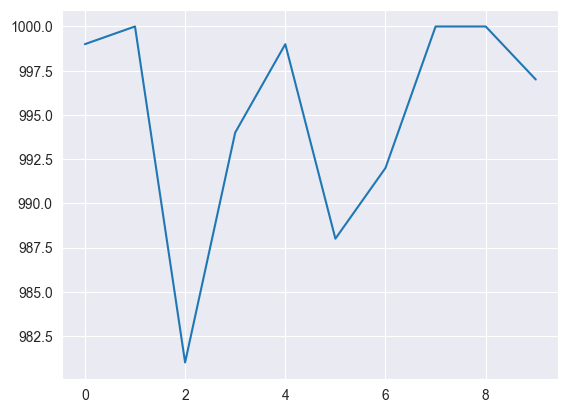

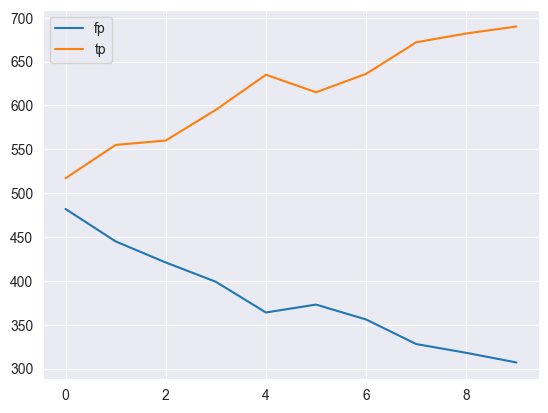

In [50]:
x=np.arange(1,11)
plt.plot(true_custom_scores[:10])
plt.show()
plt.plot(true_custom_scores_best_k[:10])
plt.show()
plt.plot(best_fp[:10],label="fp")
plt.plot(best_tp[:10],label="tp")
plt.legend()
plt.show()

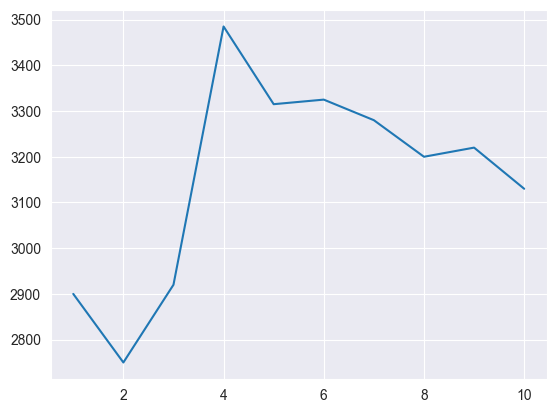

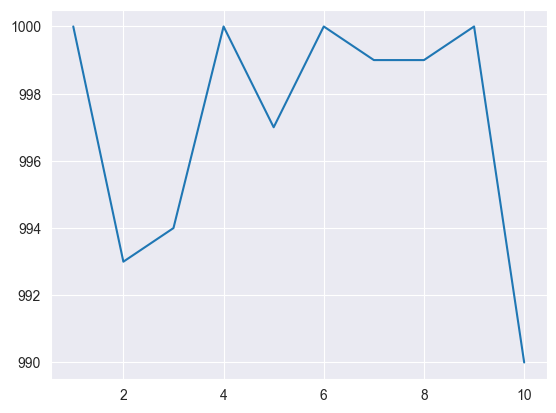

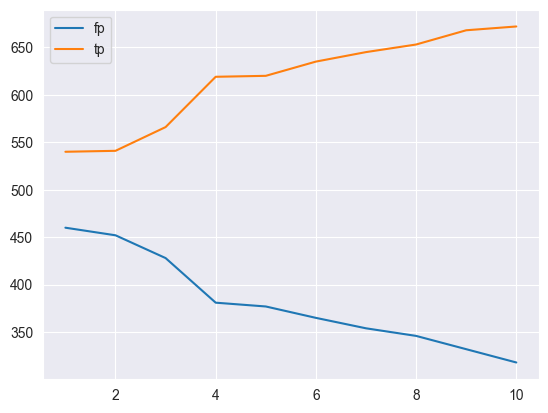

In [13]:
x=np.arange(1,11)
plt.plot(x,true_custom_scores[:10])
plt.show()
plt.plot(x,true_custom_scores_best_k[:10])
plt.show()
plt.plot(x,best_fp[:10],label="fp")
plt.plot(x,best_tp[:10],label="tp")
plt.legend()
plt.show()

In [31]:
from sklearn.feature_selection import RFE

# Initialize XGBoost as the 'selector'
estimator = XGBClassifier(n_estimators=50, random_state=42)

# Set to select exactly 10 features
selector = RFE(estimator, n_features_to_select=50, step=10)
selector = selector.fit(x_train_tr2, y_train_tr2.values.ravel())

# Get the final list
final_precision_features = x_train.columns[selector.support_].tolist()

print("The 50 Features that survived Recursive Elimination:")
print(final_precision_features)

The 50 Features that survived Recursive Elimination:
['V26', 'V27', 'V28', 'V41', 'V46', 'V55', 'V70', 'V75', 'V76', 'V100', 'V105', 'V113', 'V114', 'V117', 'V137', 'V139', 'V146', 'V149', 'V160', 'V170', 'V176', 'V178', 'V189', 'V191', 'V199', 'V215', 'V224', 'V227', 'V243', 'V255', 'V262', 'V263', 'V265', 'V283', 'V309', 'V329', 'V342', 'V353', 'V354', 'V373', 'V380', 'V390', 'V393', 'V430', 'V440', 'V444', 'V464', 'V469', 'V483', 'V498']


Starting Feature Elimination Trace...
Features: 500 | Precision: 0.6182
Features: 490 | Precision: 0.6182
Features: 480 | Precision: 0.6182
Features: 470 | Precision: 0.6067
Features: 460 | Precision: 0.6067
Features: 450 | Precision: 0.6196
Features: 440 | Precision: 0.6196
Features: 430 | Precision: 0.6227
Features: 420 | Precision: 0.6206
Features: 410 | Precision: 0.5982
Features: 400 | Precision: 0.5982
Features: 390 | Precision: 0.6057
Features: 380 | Precision: 0.6119
Features: 370 | Precision: 0.6067
Features: 360 | Precision: 0.6073
Features: 350 | Precision: 0.6057
Features: 340 | Precision: 0.6014
Features: 330 | Precision: 0.6112
Features: 320 | Precision: 0.6101
Features: 310 | Precision: 0.5962
Features: 300 | Precision: 0.6081
Features: 290 | Precision: 0.6049
Features: 280 | Precision: 0.6030
Features: 270 | Precision: 0.6083
Features: 260 | Precision: 0.6000
Features: 250 | Precision: 0.5932
Features: 240 | Precision: 0.6005
Features: 230 | Precision: 0.6053
Features: 

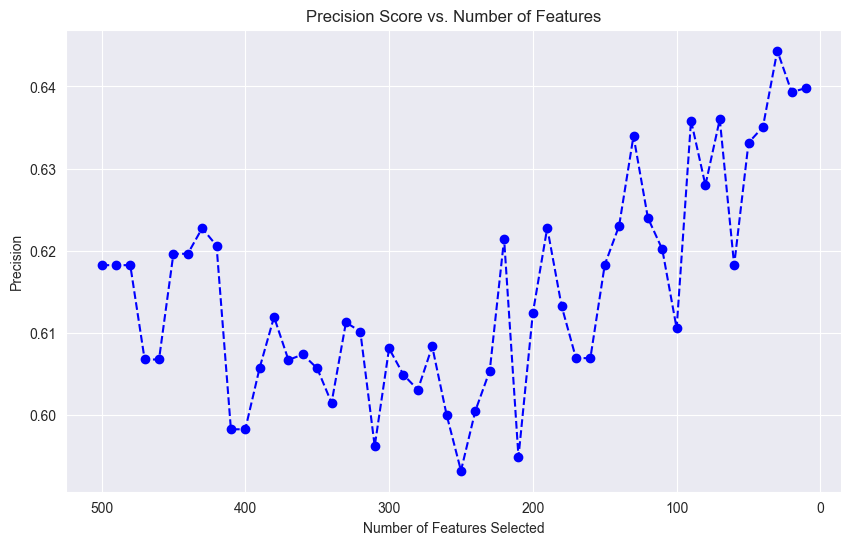

In [24]:
from sklearn.feature_selection import RFE
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt

# 1. Define the range of features you want to test
# For example: from 100 down to 10, stepping by 10
feature_counts = range(500, 9, -10)
results = []

print("Starting Feature Elimination Trace...")

for n in feature_counts:
    # Initialize RFE for the specific number of features
    selector = RFE(estimator=XGBClassifier(n_estimators=50, random_state=42),
                   n_features_to_select=n,
                   step=10)

    # Fit selector
    selector.fit(x_train_tr2, y_train_tr2.values.ravel())

    # Transform data to the selected features
    x_train_selected = selector.transform(x_train_tr2)
    x_test_selected = selector.transform(x_train_val2)

    # Train a temporary model to get the precision score
    temp_model = XGBClassifier(n_estimators=50, random_state=42)
    temp_model.fit(x_train_selected, y_train_tr2.values.ravel())

    # Predict and calculate precision
    y_pred = temp_model.predict(x_test_selected)
    score = precision_score(y_train_val2, y_pred)

    results.append(score)
    print(f"Features: {n} | Precision: {score:.4f}")


### Visualizing the Decay

plt.figure(figsize=(10, 6))
plt.plot(list(feature_counts), results, marker='o', linestyle='--', color='b')
plt.title('Precision Score vs. Number of Features')
plt.xlabel('Number of Features Selected')
plt.ylabel('Precision')
plt.grid(True)
plt.gca().invert_xaxis() # Show high features on left, low on right
plt.show()

Starting Feature Elimination Trace...
Features: 50 | Precision: 0.6070, Recall: 0.6348, Accuracy: 0.6200
Features: 45 | Precision: 0.6092, Recall: 0.6405, Accuracy: 0.6228
Features: 40 | Precision: 0.6227, Recall: 0.6405, Accuracy: 0.6340
Features: 35 | Precision: 0.6287, Recall: 0.6307, Accuracy: 0.6368
Features: 30 | Precision: 0.6294, Recall: 0.6438, Accuracy: 0.6400
Features: 25 | Precision: 0.6297, Recall: 0.6446, Accuracy: 0.6404
Features: 20 | Precision: 0.6244, Recall: 0.6560, Accuracy: 0.6384
Features: 15 | Precision: 0.6228, Recall: 0.6258, Accuracy: 0.6312
Features: 10 | Precision: 0.6205, Recall: 0.6119, Accuracy: 0.6268
Features: 5 | Precision: 0.5778, Recall: 0.5703, Accuracy: 0.5856


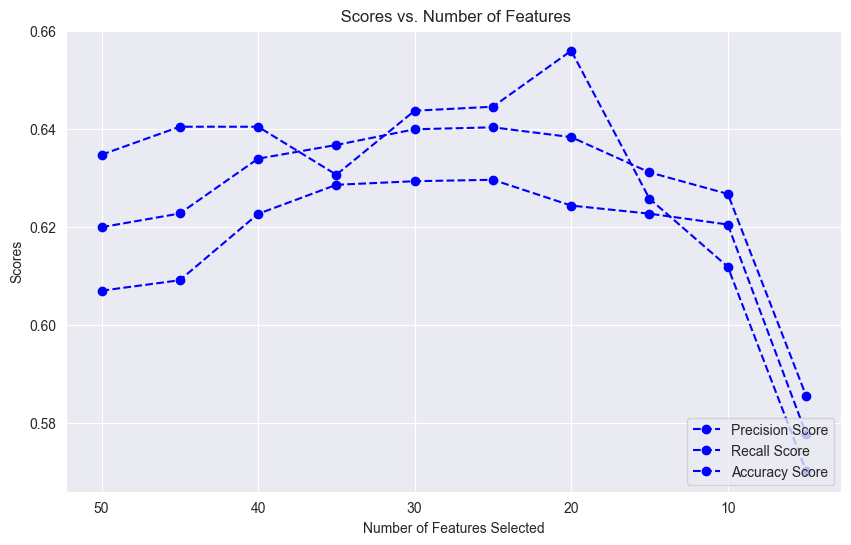

In [42]:
from sklearn.feature_selection import RFE
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt

# 1. Define the range of features you want to test
# For example: from 50 down to 5, stepping by 5
feature_counts = range(50, 4, -5)
results = []
acc=[]
rec=[]
custom=[]
print("Starting Feature Elimination Trace...")

for n in feature_counts:
    # Initialize RFE for the specific number of features
    selector = RFE(estimator=XGBClassifier(n_estimators=50, random_state=42),
                   n_features_to_select=n,
                   step=10)

    # Fit selector
    selector.fit(x_train_trsq, y_train_trsq.values.ravel())

    # Transform data to the selected features
    x_train_selected = selector.transform(x_train_trsq)
    x_test_selected = selector.transform(x_train_valsq)

    # Train a temporary model to get the precision score
    temp_model = XGBClassifier(n_estimators=50, random_state=42)
    temp_model.fit(x_train_selected, y_train_trsq.values.ravel())

    # Predict and calculate precision
    y_pred = temp_model.predict(x_test_selected)
    score = precision_score(y_train_valsq, y_pred)
    accuracy=accuracy_score(y_train_valsq, y_pred)
    recall=recall_score(y_train_valsq, y_pred)
    results.append(score)
    rec.append(recall)
    acc.append(accuracy)
    custom.append(custom)
    print(f"Features: {n} | Precision: {score:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}")


### Visualizing the Decay

plt.figure(figsize=(10, 6))
plt.plot(list(feature_counts), results, marker='o', linestyle='--', color='b',label='Precision Score')
plt.plot(list(feature_counts), rec, marker='o', linestyle='--', color='b',label='Recall Score')
plt.plot(list(feature_counts), acc, marker='o', linestyle='--', color='b',label='Accuracy Score')
plt.title(' Scores vs. Number of Features')
plt.xlabel('Number of Features Selected')
plt.ylabel('Scores')
plt.legend(loc='lower right')
plt.grid(True)
plt.gca().invert_xaxis() # Show high features on left, low on right
plt.show()

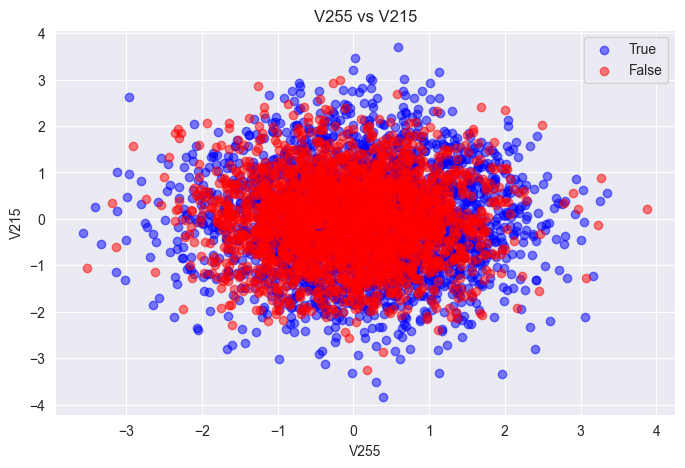

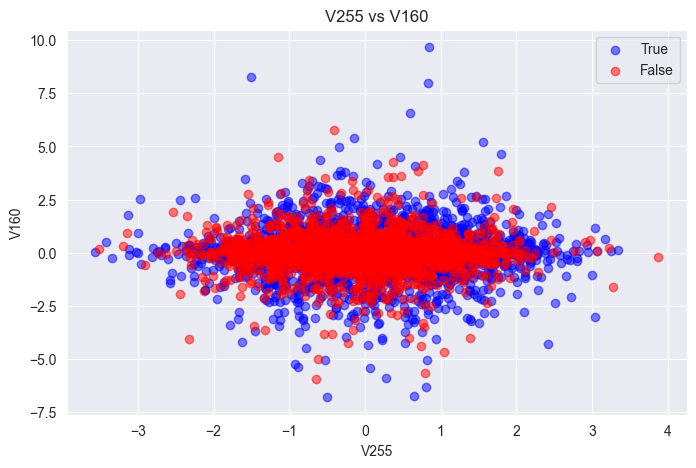

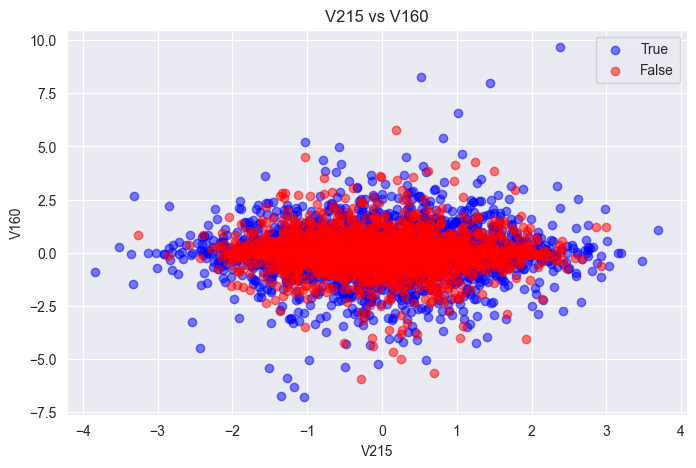

In [35]:
import matplotlib.pyplot as plt

# Plot 1: V255 vs V215
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true['V255'], x_train_true['V215'], color='blue', label='True', alpha=0.5)
plt.scatter(x_train_false['V255'], x_train_false['V215'], color='red', label='False', alpha=0.5)
plt.title('V255 vs V215')
plt.xlabel('V255')
plt.ylabel('V215')
plt.legend()
plt.show()

# Plot 2: V255 vs V160
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true['V255'], x_train_true['V160'], color='blue', label='True', alpha=0.5)
plt.scatter(x_train_false['V255'], x_train_false['V160'], color='red', label='False', alpha=0.5)
plt.title('V255 vs V160')
plt.xlabel('V255')
plt.ylabel('V160')
plt.legend()
plt.show()
# Plot 2: V215 vs V160
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true['V215'], x_train_true['V160'], color='blue', label='True', alpha=0.5)
plt.scatter(x_train_false['V215'], x_train_false['V160'], color='red', label='False', alpha=0.5)
plt.title('V215 vs V160')
plt.xlabel('V215')
plt.ylabel('V160')
plt.legend()
plt.show()

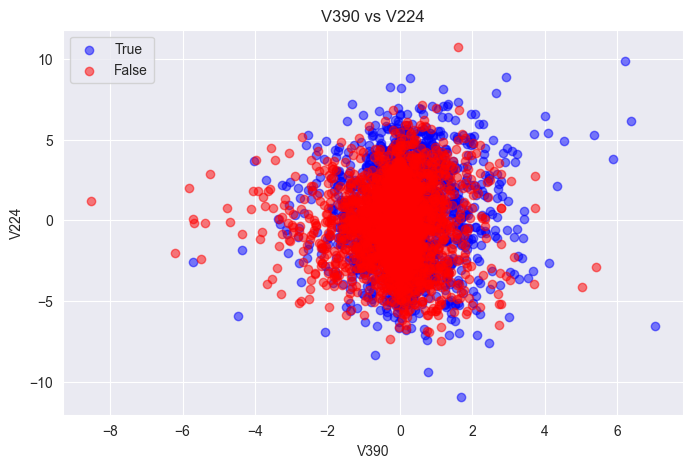

In [63]:
# Plot 2: V215 vs V160
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true['V390'], x_train_true['V224'], color='blue', label='True', alpha=0.5)
plt.scatter(x_train_false['V390'], x_train_false['V224'], color='red', label='False', alpha=0.5)
plt.title('V390 vs V224')
plt.xlabel('V390')
plt.ylabel('V224')
plt.legend()
plt.show()

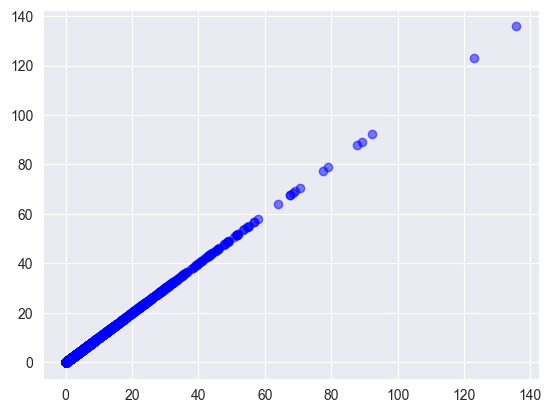

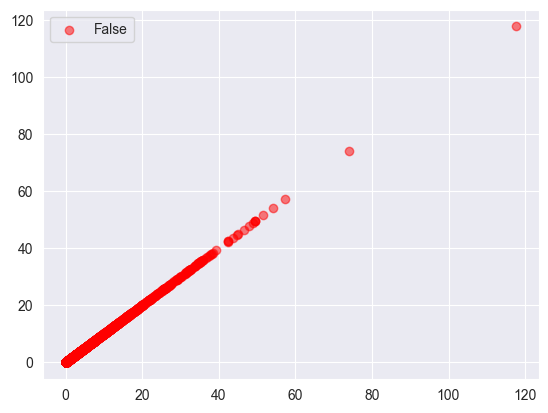

In [72]:
plt.scatter(x_train_true['V390']**2+ x_train_true['V224']**2,x_train_true['V390']**2+ x_train_true['V224']**2,color='blue', label='True', alpha=0.5)
plt.show()
plt.scatter(x_train_false['V390']**2+ x_train_false['V224']**2,x_train_false['V390']**2+ x_train_false['V224']**2,color='red', label='False', alpha=0.5)
plt.legend()
plt.show()


In [77]:
small_training=x_train.loc[:,['V390','V224']]

In [78]:
small_training['sq']=small_training['V390']**2+small_training['V224']**2

In [83]:
xgb_small1=XGBClassifier(n_estimators=50, random_state=42)


In [80]:
smtx,smvx,smty,smvy=train_test_split(small_training,y_train,test_size=0.5,random_state=42)

In [84]:
xgb_small1.fit(smtx,smty)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [85]:
y_pred_proba=xgb_small1.predict_proba(smtx)

In [86]:
y_pred=xgb_small1.predict(smtx)

In [88]:
print(accuracy_score(smvy, y_pred))

0.5152


In [65]:
print(np.mean(x_train_true['V390']))
print(np.mean(x_train_false['V390']))


0.11614838139386255
-0.10813249155417558


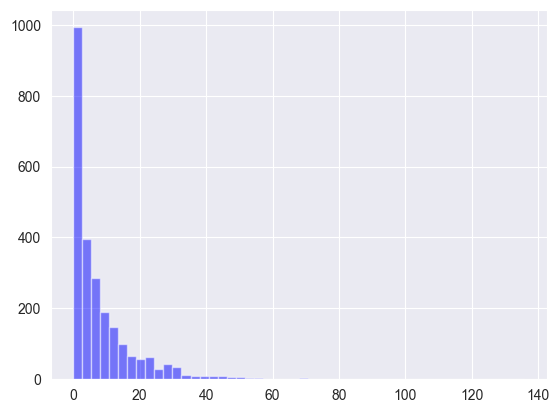

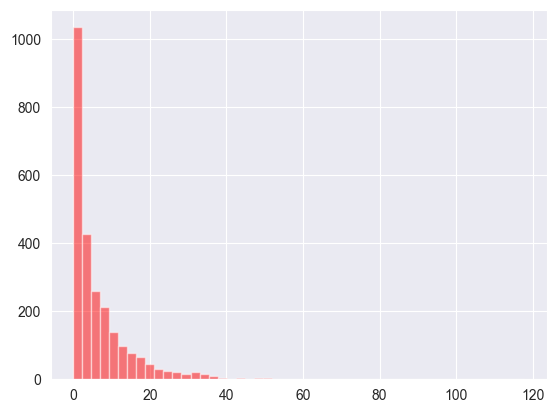

In [74]:
plt.hist(x_train_true['V390']**2+x_train_true['V224']**2, bins=50,color='blue',alpha=0.5)
plt.show()
plt.hist(x_train_false['V390']**2+x_train_false['V224']**2, bins=50,color='red',alpha=0.5)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Plot 1: V255 vs V215
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true['V255'], x_train_true['V215'], color='blue', label='True', alpha=0.5)
plt.scatter(x_train_false['V255'], x_train_false['V215'], color='red', label='False', alpha=0.5)
plt.title('V255 vs V215')
plt.xlabel('V255')
plt.ylabel('V215')
plt.legend()
plt.show()

# Plot 2: V255 vs V160
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true['V255'], x_train_true['V160'], color='blue', label='True', alpha=0.5)
plt.scatter(x_train_false['V255'], x_train_false['V160'], color='red', label='False', alpha=0.5)
plt.title('V255 vs V160')
plt.xlabel('V255')
plt.ylabel('V160')
plt.legend()
plt.show()
# Plot 2: V215 vs V160
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true['V215'], x_train_true['V160'], color='blue', label='True', alpha=0.5)
plt.scatter(x_train_false['V215'], x_train_false['V160'], color='red', label='False', alpha=0.5)
plt.title('V215 vs V160')
plt.xlabel('V215')
plt.ylabel('V160')
plt.legend()
plt.show()

In [38]:
# Create new DataFrames with squared values
x_train_true_sq = x_train_true ** 2
x_train_false_sq = x_train_false ** 2

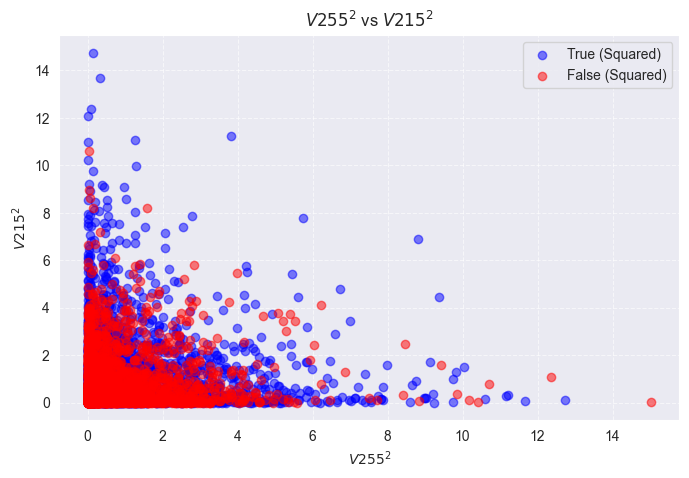

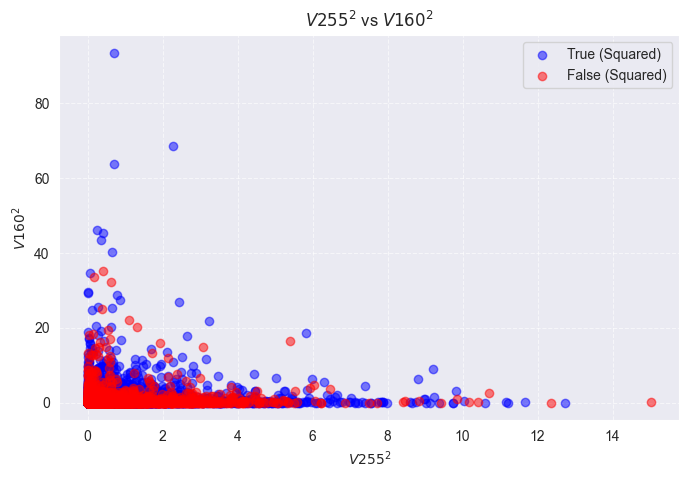

In [39]:
import matplotlib.pyplot as plt

# Plot 1: V255^2 vs V215^2
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true_sq['V255'], x_train_true_sq['V215'], color='blue', label='True (Squared)', alpha=0.5)
plt.scatter(x_train_false_sq['V255'], x_train_false_sq['V215'], color='red', label='False (Squared)', alpha=0.5)

plt.title('$V255^2$ vs $V215^2$')
plt.xlabel('$V255^2$')
plt.ylabel('$V215^2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot 2: V255^2 vs V160^2
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true_sq['V255'], x_train_true_sq['V160'], color='blue', label='True (Squared)', alpha=0.5)
plt.scatter(x_train_false_sq['V255'], x_train_false_sq['V160'], color='red', label='False (Squared)', alpha=0.5)

plt.title('$V255^2$ vs $V160^2$')
plt.xlabel('$V255^2$')
plt.ylabel('$V160^2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

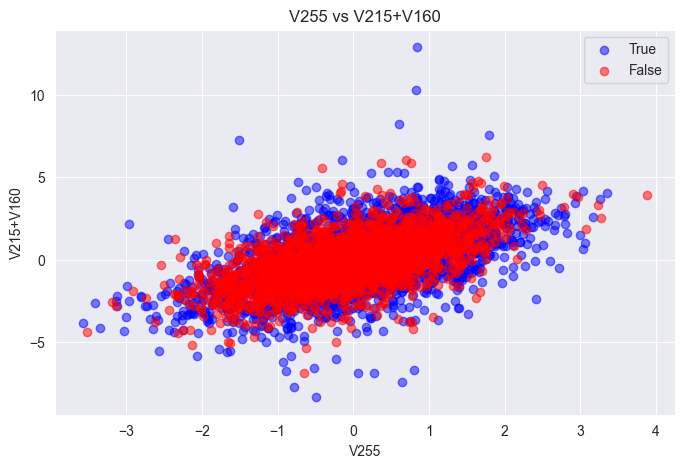

In [37]:
import matplotlib.pyplot as plt

# Plot 1: V255 vs V215
plt.figure(figsize=(8, 5))
plt.scatter(x_train_true['V255'], x_train_true['V215']+x_train_true['V160']+x_train_true['V255'], color='blue', label='True', alpha=0.5)
plt.scatter(x_train_false['V255'], x_train_false['V215']+x_train_false['V160']+x_train_false['V255'], color='red', label='False', alpha=0.5)
plt.title('V255 vs V215+V160')
plt.xlabel('V255')
plt.ylabel('V215+V160')
plt.legend()
plt.show()

# # Plot 2: V215 vs V160
# plt.figure(figsize=(8, 5))
# plt.scatter(x_train_true['V215'],x_train_true['V160'], color='blue', label='True', alpha=0.5)
# plt.scatter(x_train_false['V215'], x_train_false['V160'], color='red', label='False', alpha=0.5)
# plt.title('V215 vs V160')
# plt.xlabel('V215')
# plt.ylabel('V160')
# plt.legend()
# plt.show()

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from xgboost import XGBClassifier

selected_features = {
    i: [] for i in range(1, 26)
}

# Base estimator
estimator = XGBClassifier(n_estimators=50, random_state=42)

# Forward Feature Selection
for i in range(1, 26):

    selector = SequentialFeatureSelector(
        estimator,
        n_features_to_select=i,
        direction="forward",
        scoring="accuracy",
        cv=5,
        n_jobs=-1
    )

    selector.fit(x_train_tr2, y_train_tr2.values.ravel())

    # Get selected feature names
    selected_features[i] = x_train_tr2.columns[selector.get_support()].tolist()

    print(f"\nTop {i} selected features:")
    print(selected_features[i])


Top 1 selected features:
['V361']

Top 2 selected features:
['V169', 'V361']


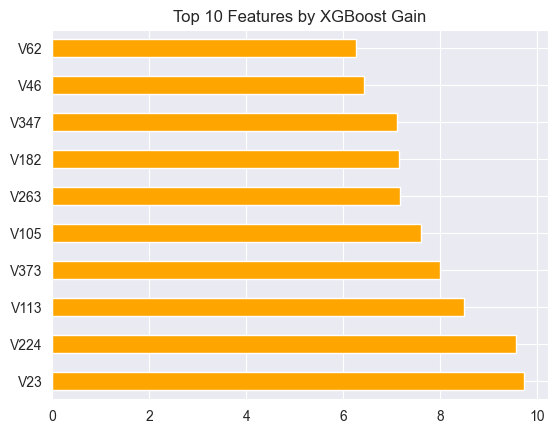

In [23]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Train on ALL features first (or a large subset)
model = xgb.XGBClassifier()
model.fit(x_train_tr2, y_train_tr2)

# 2. Get the "Gain" importance (this is usually best for precision)
# 'gain' is the average reduction in loss brought by a feature
importances = model.get_booster().get_score(importance_type='gain')

# 3. Convert to Series and plot
xgb_importance = pd.Series(importances).sort_values(ascending=False)
xgb_importance.head(10).plot(kind='barh', color='orange')
plt.title('Top 10 Features by XGBoost Gain')
plt.show()

In [24]:
best_xgb_gain_cols=xgb_importance.head(10).index

In [25]:
best_xgb_gain_cols

Index(['V23', 'V224', 'V113', 'V373', 'V105', 'V263', 'V182', 'V347', 'V46',
       'V62'],
      dtype='str')

In [26]:
from scoring_function import score_model_optimal_k
true_custom_scores=np.zeros(10)
true_custom_scores_best_k=np.zeros(10)
best_fp=np.zeros(10)
best_tp=np.zeros(10)
for i in range(10):
    selected_cols=best_xgb_gain_cols[:i+1]
    train_data=x_train_tr2.loc[:,selected_cols]
    test_data=x_train_val2.loc[:,selected_cols]
    xgb=XGBClassifier()
    xgb.fit(train_data,y_train_tr2)
    positive_probas=xgb.predict_proba(test_data)[:,1]
    true_custom_scores[i],true_custom_scores_best_k[i],best_fp[i],best_tp[i]=score_model_optimal_k(y_train_val2,positive_probas,i+1,keep_fp_tp=True)
    if i%5==0:
        print(f"{i} iters done")

0 iters done
5 iters done


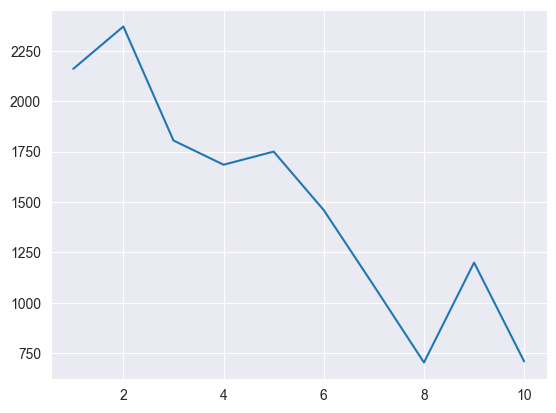

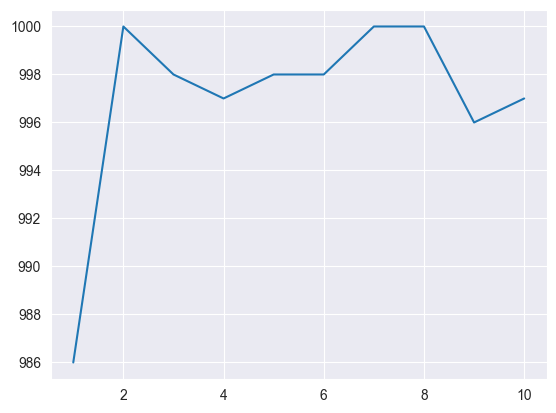

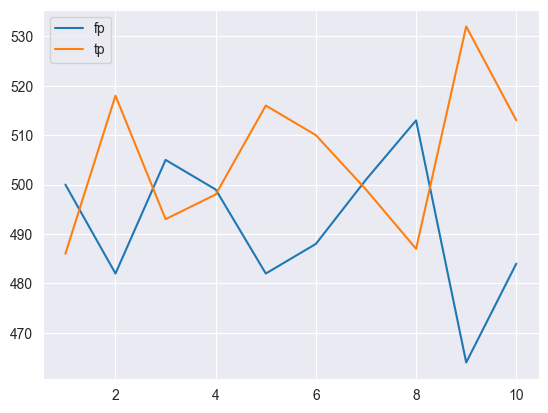

In [27]:
x=np.arange(1,11)
plt.plot(x,true_custom_scores[:10])
plt.show()
plt.plot(x,true_custom_scores_best_k[:10])
plt.show()
plt.plot(x,best_fp[:10],label="fp")
plt.plot(x,best_tp[:10],label="tp")
plt.legend()
plt.show()

In [105]:
import xgboost as xgb
import pandas as pd

# 1. Fit the model on the full training set
# (Ensure x_train has all 500 columns)
clf = xgb.XGBClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train.values.ravel())

# 2. Extract importance scores based on 'gain'
# Gain is the most reliable metric for precision/accuracy
importance_dict = clf.get_booster().get_score(importance_type='gain')

# 3. Convert to a sorted Series
xgb_top_features = pd.Series(importance_dict).sort_values(ascending=False)

# 4. Get the Top 10 Names
top_20_xgb_names = xgb_top_features.head(20).index.tolist()

print("The Top 10 Features chosen by XGBoost:")
print(top_20_xgb_names)

The Top 10 Features chosen by XGBoost:
['V11', 'V265', 'V176', 'V174', 'V160', 'V191', 'V46', 'V255', 'V136', 'V425']


In [83]:
selected_cols[:4]

['V390', 'V224', 'V161', 'V175']

In [48]:
thresholds=[0.5,0.6,0.7,0.8,0.9]
for i in range(50):
    selected_cols=sorted_col_names[:i+1]
    train_data=x_train_tr2.loc[:,selected_cols]
    test_data=x_train_val2.loc[:,selected_cols]
    xgb=XGBClassifier()
    xgb.fit(train_data,y_train_tr2)
    positive_probas=xgb.predict_proba(test_data)[:,1]
    for t in thresholds:
        y_pred4=(positive_probas >= t).astype(int)
        custom_scores[t][i]=customresultscore(y_pred4,y_train_val2)
        accuracy_scores[t][i]=accuracy_score(y_train_val2,y_pred4)
        precision_scores[t][i]=precision_score(y_train_val2,y_pred4)

tp count=641, fp count=604
tp count=378, fp count=317
tp count=143, fp count=94
tp count=22, fp count=19
tp count=2, fp count=3
tp count=630, fp count=600
tp count=454, fp count=389
tp count=269, fp count=218
tp count=136, fp count=96
tp count=57, fp count=32
tp count=674, fp count=605
tp count=502, fp count=434
tp count=329, fp count=278
tp count=180, fp count=131
tp count=70, fp count=35
tp count=696, fp count=577
tp count=519, fp count=417
tp count=376, fp count=260
tp count=230, fp count=135
tp count=92, fp count=46
tp count=696, fp count=577
tp count=519, fp count=417
tp count=376, fp count=260
tp count=230, fp count=135
tp count=92, fp count=46
tp count=679, fp count=606
tp count=505, fp count=433
tp count=336, fp count=253
tp count=196, fp count=128
tp count=73, fp count=41
tp count=669, fp count=574
tp count=543, fp count=416
tp count=396, fp count=280
tp count=242, fp count=150
tp count=105, fp count=52
tp count=661, fp count=568
tp count=533, fp count=392
tp count=379, fp cou

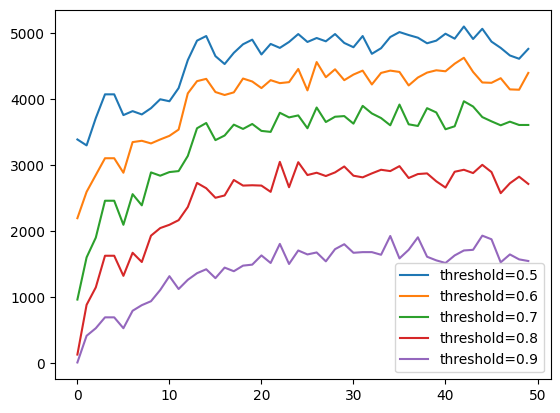

In [49]:
x=np.arange(0,50)
for t in thresholds:
    plt.plot(x,custom_scores[t][:50],label=f"threshold={t}")
plt.legend()
plt.show()

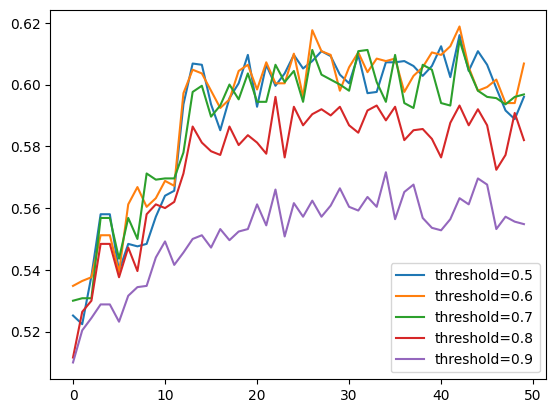

In [50]:
x=np.arange(0,50)
for t in thresholds:
    plt.plot(x,accuracy_scores[t][:50],label=f"threshold={t}")
plt.legend()
plt.show()

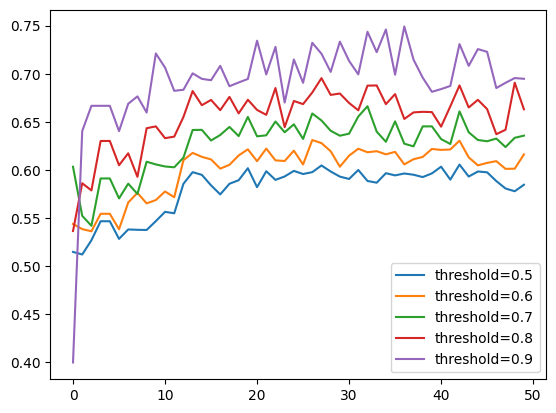

In [51]:
x=np.arange(0,50)
for t in thresholds:
    plt.plot(x,precision_scores[t][:50],label=f"threshold={t}")
plt.legend()
plt.show()

In [42]:
custom_scores2={
    0.5:np.zeros(50),
    0.6:np.zeros(50),
    0.7:np.zeros(50),
    0.8:np.zeros(50),
    0.9:np.zeros(50)
}
accuracy_scores2={
    0.5:np.zeros(50),
    0.6:np.zeros(50),
    0.7:np.zeros(50),
    0.8:np.zeros(50),
    0.9:np.zeros(50)
}
precision_scores2={
    0.5:np.zeros(50),
    0.6:np.zeros(50),
    0.7:np.zeros(50),
    0.8:np.zeros(50),
    0.9:np.zeros(50)
}
thresholds=[0.5,0.6,0.7,0.8,0.9]
for i in range(50):
    selected_cols=sorted_col_names[:i+1]
    train_data=x_train_tr1.loc[:,selected_cols]
    test_data=x_train_val.loc[:,selected_cols]
    xgb=XGBClassifier()
    xgb.fit(train_data,y_train_tr1)
    positive_probas=xgb.predict_proba(train_data)[:,1]
    for t in thresholds:
        y_pred4=(positive_probas >= t).astype(int)
        custom_scores2[t][i]=customresultscore(y_pred4,y_train_tr1)
        accuracy_scores2[t][i]=accuracy_score(y_train_tr1,y_pred4)
        precision_scores2[t][i]=precision_score(y_train_tr1,y_pred4)
    if i%10==0:
        print(f"done {i} rounds")

tp count=1231, fp count=761
tp count=724, fp count=336
tp count=176, fp count=44
tp count=68, fp count=10
tp count=15, fp count=1
done 0 rounds
tp count=1620, fp count=359
tp count=1152, fp count=102
tp count=699, fp count=22
tp count=389, fp count=1
tp count=124, fp count=0
tp count=1744, fp count=190
tp count=1407, fp count=53
tp count=957, fp count=7
tp count=496, fp count=1
tp count=165, fp count=0
tp count=1852, fp count=93
tp count=1606, fp count=17
tp count=1188, fp count=2
tp count=723, fp count=0
tp count=262, fp count=0
tp count=1852, fp count=93
tp count=1606, fp count=17
tp count=1188, fp count=2
tp count=723, fp count=0
tp count=262, fp count=0
tp count=1875, fp count=63
tp count=1673, fp count=10
tp count=1298, fp count=0
tp count=804, fp count=0
tp count=283, fp count=0
tp count=1920, fp count=29
tp count=1743, fp count=6
tp count=1421, fp count=0
tp count=947, fp count=0
tp count=386, fp count=0
tp count=1930, fp count=14
tp count=1771, fp count=0
tp count=1494, fp coun

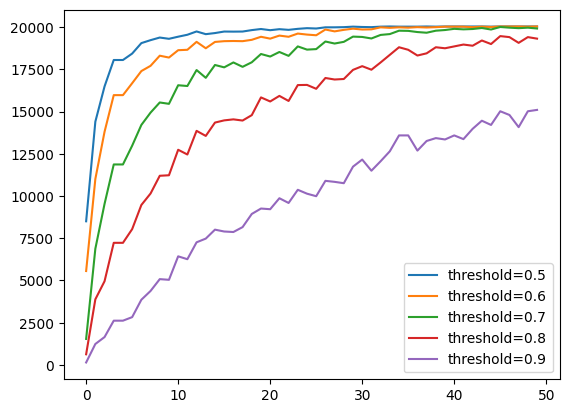

In [43]:
x=np.arange(0,50)
for t in thresholds:
    plt.plot(x,custom_scores2[t],label=f"threshold={t}")
plt.legend()
plt.show()

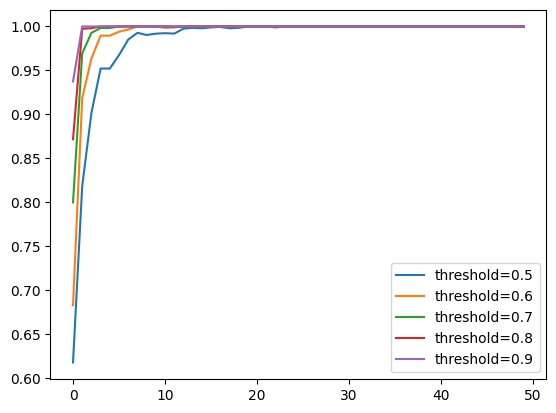

In [44]:
x=np.arange(0,50)
for t in thresholds:
    plt.plot(x,precision_scores2[t],label=f"threshold={t}")
plt.legend()
plt.show()

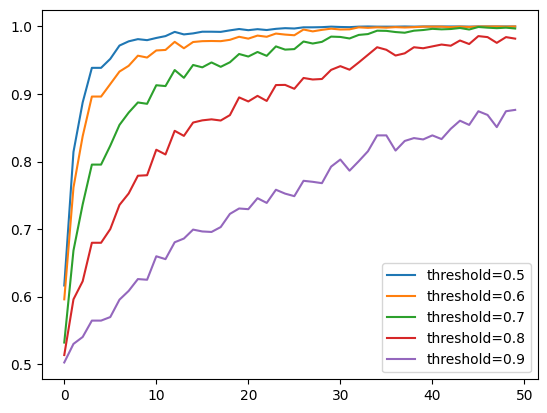

In [45]:
x=np.arange(0,50)
for t in thresholds:
    plt.plot(x,accuracy_scores2[t],label=f"threshold={t}")
plt.legend()
plt.show()

In [44]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(x_train_tr1,y_train_tr1)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [22]:
print(len(y_train_val))
print(np.sum(y_train_val))


1000
484


In [25]:
dummy=np.ones(len(y_train_val))
print(customresultscore(dummy,y_train_val))

tp count=484000, fp count=516000
2260000


In [35]:
y_true = np.asarray(y_train_val)
print(np.sum(y_true))
# print(np.sum(dummy))
# print(len(dummy))
np.sum((dummy == 1) & (y_true == 1))

484


np.int64(484000)

In [16]:
lr.fit(x_train_tr1,y_train_tr1)

C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

run for threshold: 0.0
ones in y_pred4: 1000
tp count=484, fp count=516
run for threshold: 0.02040816326530612
ones in y_pred4: 1000
tp count=484, fp count=516
run for threshold: 0.04081632653061224
ones in y_pred4: 1000
tp count=484, fp count=516
run for threshold: 0.061224489795918366
ones in y_pred4: 991
tp count=482, fp count=509
run for threshold: 0.08163265306122448
ones in y_pred4: 985
tp count=480, fp count=505
run for threshold: 0.1020408163265306
ones in y_pred4: 976
tp count=476, fp count=500
run for threshold: 0.12244897959183673
ones in y_pred4: 963
tp count=473, fp count=490
run for threshold: 0.14285714285714285
ones in y_pred4: 958
tp count=469, fp count=489
run for threshold: 0.16326530612244897
ones in y_pred4: 950
tp count=467, fp count=483
run for threshold: 0.18367346938775508
ones in y_pred4: 935
tp count=461, fp count=474
run for threshold: 0.2040816326530612
ones in y_pred4: 912
tp count=451, fp count=461
run for threshold: 0.22448979591836732
ones in y_pred4: 8

C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

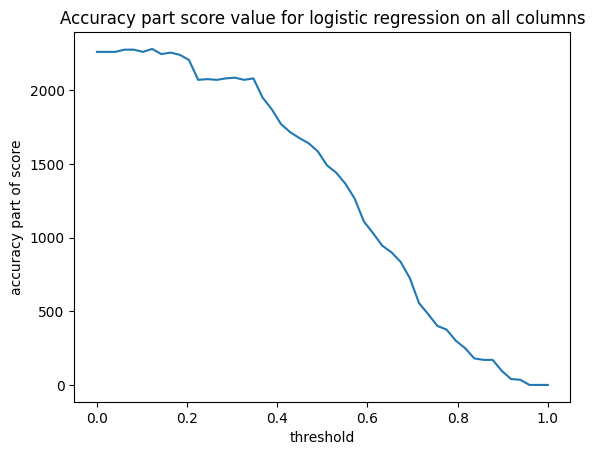

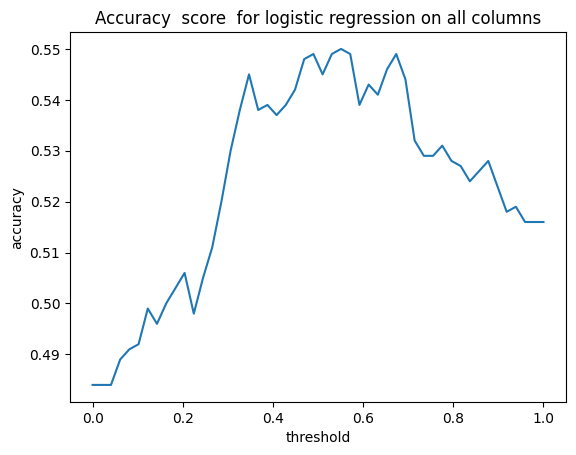

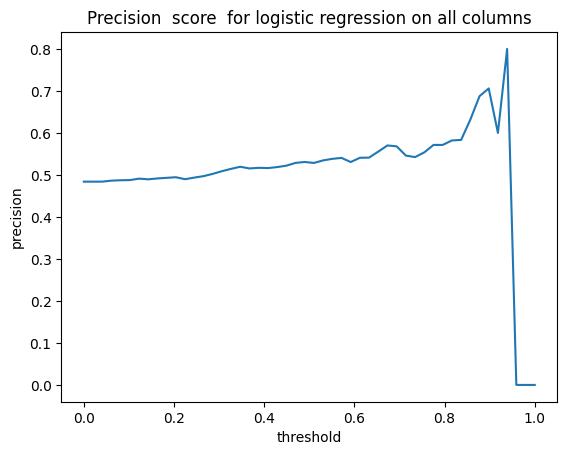

In [41]:
from sklearn.metrics import accuracy_score,precision_score
probas_predict=lr.predict_proba(x_train_val)
thresholds=np.linspace(0,1,50)
scores=np.zeros(len(thresholds))
accuracys=np.zeros(len(thresholds))
precs=np.zeros(len(thresholds))
for i in range(len(thresholds)):
    threshold=thresholds[i]
    print(f"run for threshold: {threshold}")
    y_pred4=(probas_predict[:,1] >= threshold).astype(int)
    print(f"ones in y_pred4: {np.sum(y_pred4)}")
    scores[i]=customresultscore(y_pred4,y_train_val)
    accuracys[i]=accuracy_score(y_train_val,y_pred4)
    precs[i]=precision_score(y_train_val,y_pred4)
    # ConfusionMatrixDisplay.from_predictions(y_train_val, y_pred4, cmap='Blues')
    # plt.show()
plt.plot(thresholds,scores)
plt.title("Accuracy part score value for logistic regression on all columns")
plt.xlabel("threshold")
plt.ylabel("accuracy part of score")
plt.show()
plt.plot(thresholds,accuracys)
plt.title("Accuracy  score  for logistic regression on all columns")
plt.xlabel("threshold")
plt.ylabel("accuracy")
plt.show()
plt.plot(thresholds,precs)
plt.title("Precision  score  for logistic regression on all columns")
plt.xlabel("threshold")
plt.ylabel("precision")
plt.show()


run for threshold: 0.0
ones in y_pred4: 1000
tp count=484, fp count=516
run for threshold: 0.02040816326530612
ones in y_pred4: 996
tp count=484, fp count=512
run for threshold: 0.04081632653061224
ones in y_pred4: 974
tp count=478, fp count=496
run for threshold: 0.061224489795918366
ones in y_pred4: 946
tp count=467, fp count=479
run for threshold: 0.08163265306122448
ones in y_pred4: 923
tp count=462, fp count=461
run for threshold: 0.1020408163265306
ones in y_pred4: 901
tp count=455, fp count=446
run for threshold: 0.12244897959183673
ones in y_pred4: 878
tp count=448, fp count=430
run for threshold: 0.14285714285714285
ones in y_pred4: 856
tp count=442, fp count=414
run for threshold: 0.16326530612244897
ones in y_pred4: 832
tp count=436, fp count=396
run for threshold: 0.18367346938775508
ones in y_pred4: 810
tp count=431, fp count=379
run for threshold: 0.2040816326530612
ones in y_pred4: 775
tp count=418, fp count=357
run for threshold: 0.22448979591836732
ones in y_pred4: 752

C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


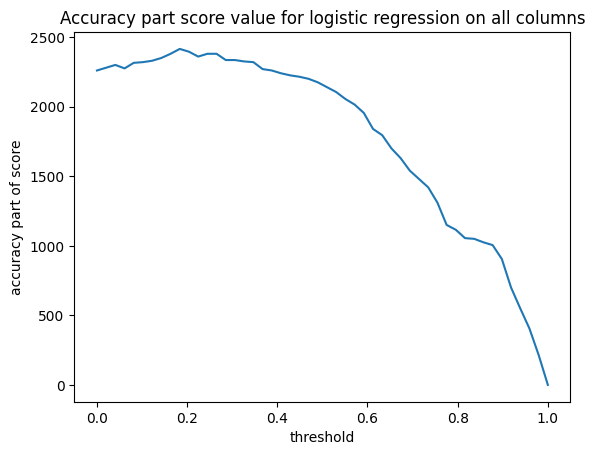

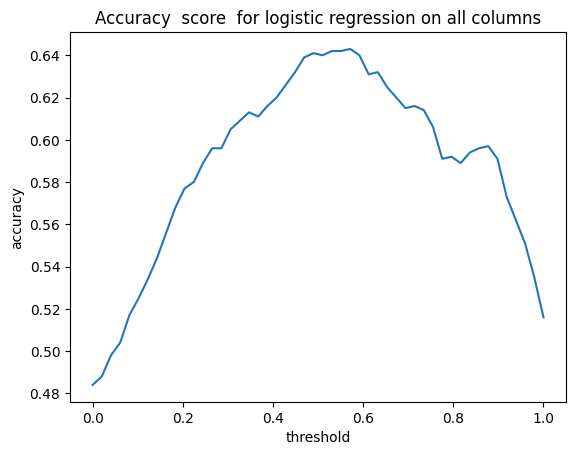

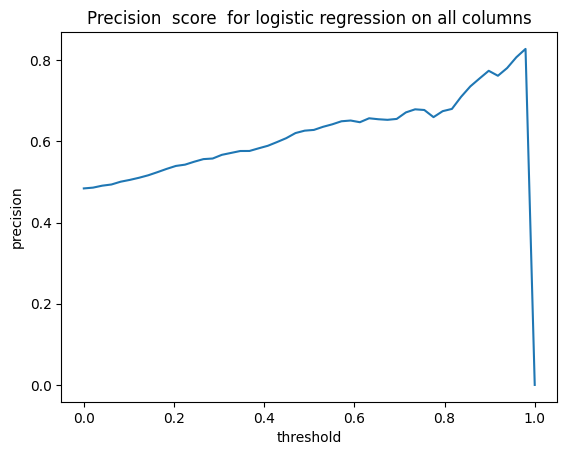

In [45]:
from sklearn.metrics import accuracy_score,precision_score
probas_predict=xgb.predict_proba(x_train_val)
thresholds=np.linspace(0,1,50)
scores=np.zeros(len(thresholds))
accuracys=np.zeros(len(thresholds))
precs=np.zeros(len(thresholds))
for i in range(len(thresholds)):
    threshold=thresholds[i]
    print(f"run for threshold: {threshold}")
    y_pred4=(probas_predict[:,1] >= threshold).astype(int)
    print(f"ones in y_pred4: {np.sum(y_pred4)}")
    scores[i]=customresultscore(y_pred4,y_train_val)
    accuracys[i]=accuracy_score(y_train_val,y_pred4)
    precs[i]=precision_score(y_train_val,y_pred4)
    # ConfusionMatrixDisplay.from_predictions(y_train_val, y_pred4, cmap='Blues')
    # plt.show()
plt.plot(thresholds,scores)
plt.title("Accuracy part score value for logistic regression on all columns")
plt.xlabel("threshold")
plt.ylabel("accuracy part of score")
plt.show()
plt.plot(thresholds,accuracys)
plt.title("Accuracy  score  for logistic regression on all columns")
plt.xlabel("threshold")
plt.ylabel("accuracy")
plt.show()
plt.plot(thresholds,precs)
plt.title("Precision  score  for logistic regression on all columns")
plt.xlabel("threshold")
plt.ylabel("precision")
plt.show()


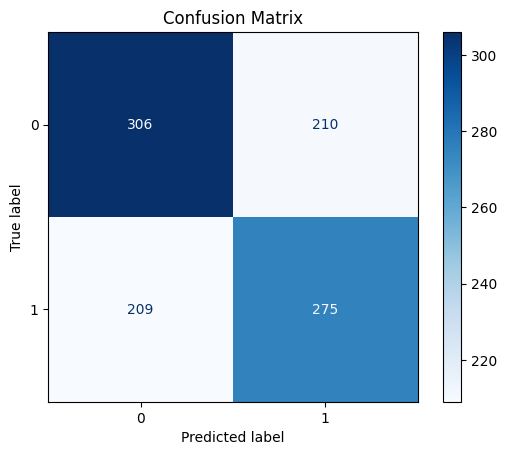

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
y_pred=lr.predict(x_train_val)
ConfusionMatrixDisplay.from_predictions(y_train_val, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

confusion matrix for threshold: 0.5


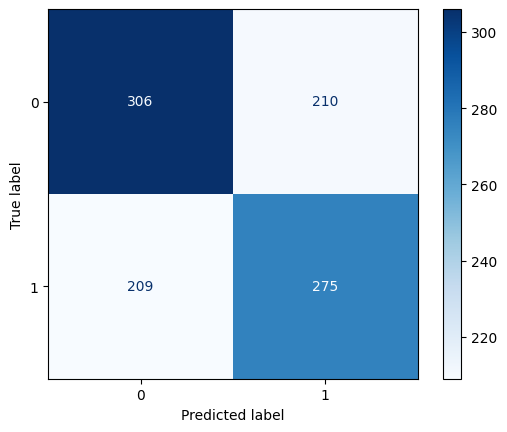

confusion matrix for threshold: 0.55


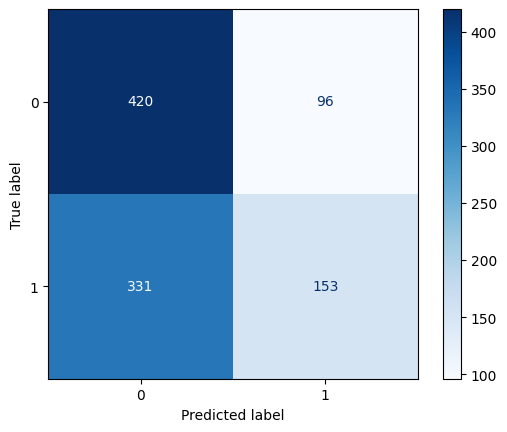

confusion matrix for threshold: 0.6


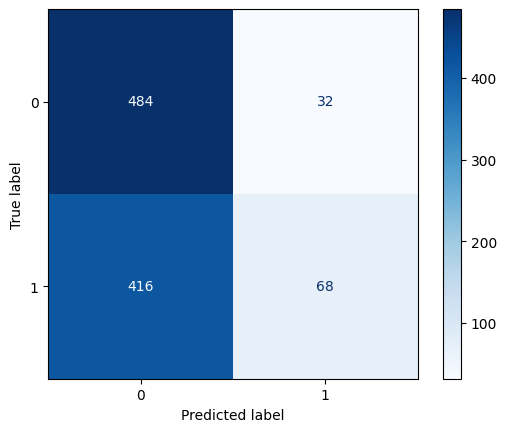

confusion matrix for threshold: 0.65


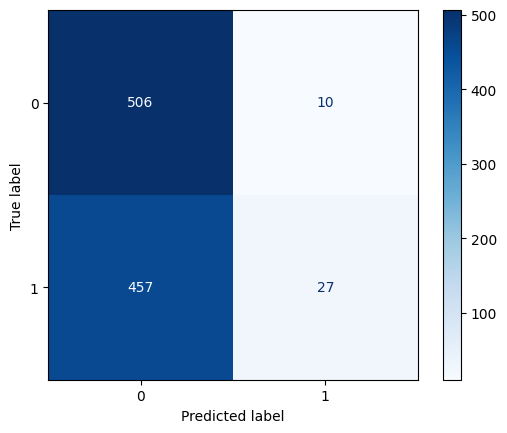

confusion matrix for threshold: 0.7


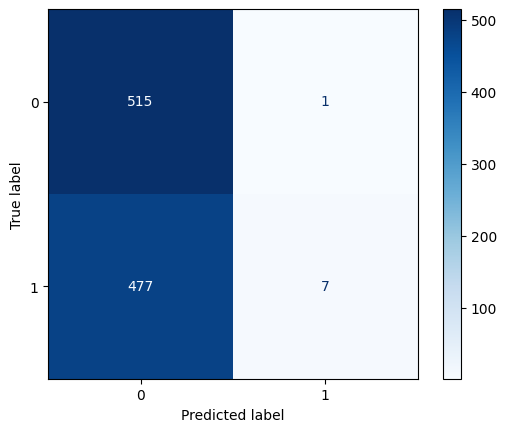

confusion matrix for threshold: 0.75


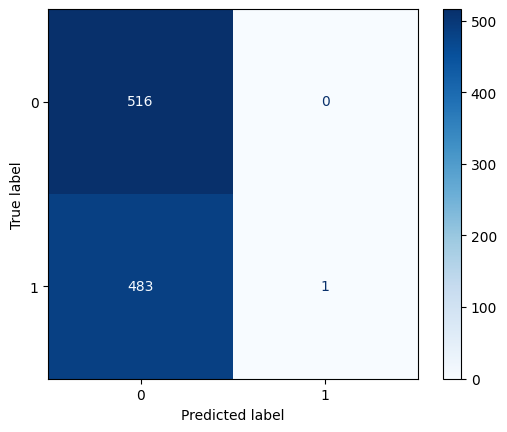

confusion matrix for threshold: 0.8


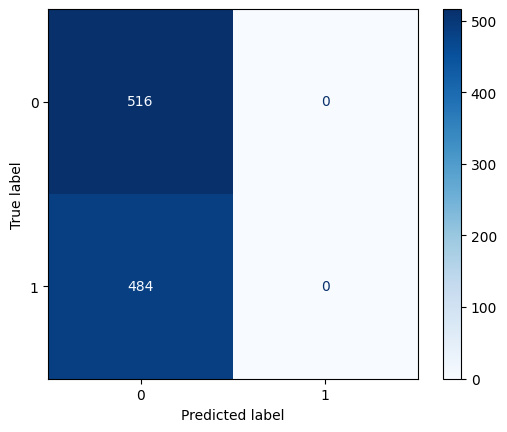

confusion matrix for threshold: 0.85


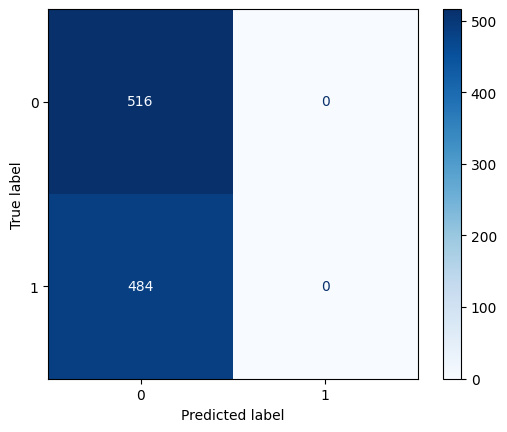

In [32]:
probas_predict=lr.predict_proba(x_train_val)
for threshold in [0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85]:
    print(f"confusion matrix for threshold: {threshold}")
    y_pred4=(probas_predict[:,1] >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_train_val, y_pred4, cmap='Blues')
    plt.show()

C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


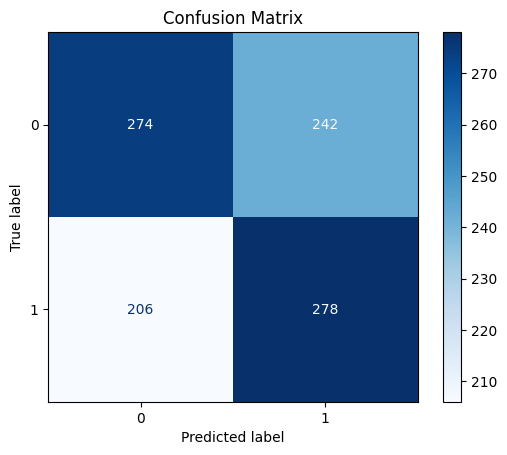

In [18]:
lr2=LogisticRegression(penalty='l1',solver='liblinear',C=2)
x_train_tr2,x_train_val2,y_train_tr2,y_train_val2=train_test_split(x_train,y_train,test_size=0.2,random_state=0)
lr2.fit(x_train_tr2,y_train_tr2)
y_pred2=lr2.predict(x_train_val2)
ConfusionMatrixDisplay.from_predictions(y_train_val2, y_pred2, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [19]:
lr2.coef_

array([[ 1.32652183e-01,  1.56121797e-01,  9.73536361e-03,
        -1.62809211e-02,  0.00000000e+00,  2.54227044e-01,
         0.00000000e+00,  4.28036535e-02, -1.16357542e-02,
         3.33799936e-02,  0.00000000e+00, -3.21835080e-03,
         6.01865509e-02, -1.70571185e-01, -1.87357545e-02,
         4.52547575e-02, -4.48940851e-02,  4.19747121e-02,
         2.40035022e-02,  8.13310905e-03,  7.38978453e-03,
        -2.49992228e-02,  3.51835617e-02,  1.01443299e-02,
        -1.19901694e-02, -1.00718303e-01,  3.65280041e-01,
         3.62369143e-02,  1.21536368e-02, -1.19904515e-01,
        -2.73429050e-02,  1.41436524e-01,  3.84716771e-03,
         4.87909996e-03,  1.14829765e-01, -5.94033145e-02,
         5.50896367e-02,  6.72964536e-03, -6.35180877e-02,
         2.25496673e-02, -1.66017013e-02, -1.18249608e-01,
         1.04404019e-01, -7.19150714e-02,  3.43543442e-03,
         0.00000000e+00, -5.16253637e-02,  2.62311838e-02,
         4.25218796e-02, -4.73768243e-03, -4.06902573e-0

In [23]:
non_zero_count = np.sum(lr2.coef_ != 0)

In [24]:
print(non_zero_count)

478


In [42]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(x_train_tr1,y_train_val)
# y_pred3=xgb.predict(x_train_val2)
# ConfusionMatrixDisplay.from_predictions(y_train_val2, y_pred3, cmap='Blues')

XGBoostError: [10:30:08] C:\actions-runner\_work\xgboost\xgboost\src\data\data.cc:522: Check failed: p_info->Size() % n_samples == 0 (1000 vs. 0) : Invalid size for `label`:(1000,1). n_samples:4000

confusion matrix for threshold: 0.5


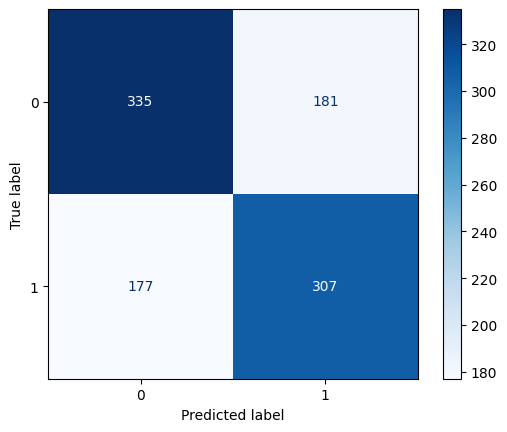

confusion matrix for threshold: 0.6


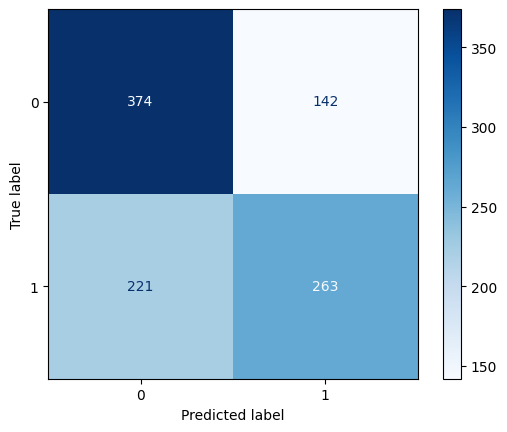

confusion matrix for threshold: 0.65


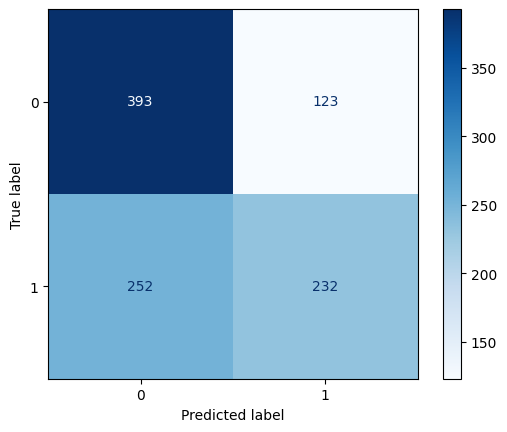

confusion matrix for threshold: 0.7


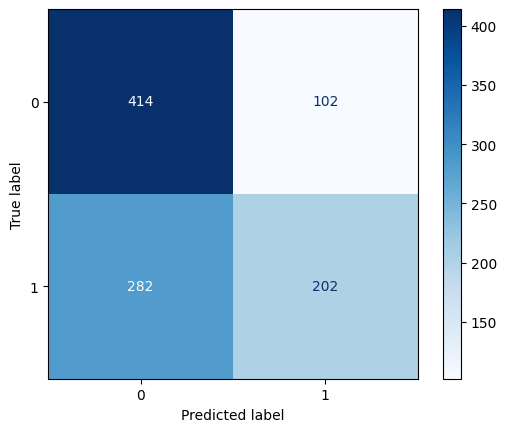

confusion matrix for threshold: 0.75


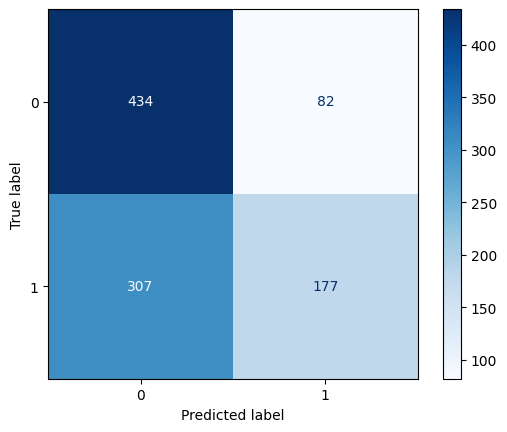

confusion matrix for threshold: 0.8


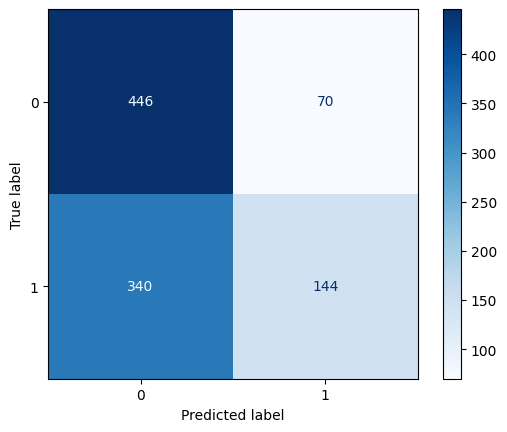

confusion matrix for threshold: 0.85


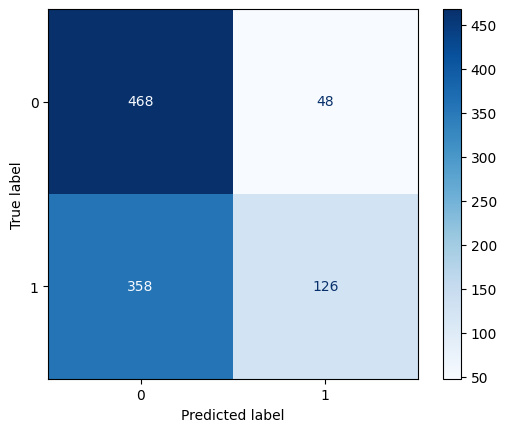

In [30]:
probas_predict=xgb.predict_proba(x_train_val2)
for threshold in [0.5,0.6,0.65,0.7,0.75,0.8,0.85]:
    print(f"confusion matrix for threshold: {threshold}")
    y_pred4=(probas_predict[:,1] >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_train_val2, y_pred4, cmap='Blues')
    plt.show()
